# Cognitive & Behavioral Predictors of Student Outcomes

**Group Members:** Mohammad Zoraiz (mz248), Rithik Duvva (rrd18), Kartikeye Gupta (kg330), Ratish Korrapati (rsk49), Enoch Li (yel6)  
**Course:** CS216 Everything Data (Spring 2026)  
**Date:** Feb 19, 2026  
**Repo:** [CampusSignals](https://github.com/zoraizmohammad/CampusSignals)  

## AI Disclosure
Artificial Intelligence Tools: ChatGPT (OpenAI, ChatGPT Edu via Duke University, accessed Jan–Feb 2026)  
- Conceptualization: refined and narrowed research questions.  
- Information collection: located documented, non-synthetic datasets and documentation.  
- Methodology support: suggested mediation-style analysis + supervised ML with ablation testing.  
- Writing/review/editing: improved structure and clarity.

---

## Research Questions
1. How do screen-use patterns (including type), sleep characteristics, and behavioral indicators relate to academic outcomes (grades/GPA proxies)?
2. To what extent do sleep characteristics mediate the relationship between screen use and academic outcomes?
3. Can we predict student outcomes from behavioral and sleep-related features, and which feature groups contribute most?

---

## Modules (mapped to this notebook)
- **Visualization (Module 3):** distributions, relationships, stratified plots, model diagnostics.
- **Data Wrangling (Module 4):** missingness handling, encoding, feature engineering.
- **Statistical Inference (Module 7):** multivariable regression + mediation-style inference with uncertainty.
- **Prediction & Supervised ML (Module 8):** cross-validation, ablations, and interpretability/feature importance.

---

## Notebook Output
This notebook runs the same analysis workflow independently on:
- **Dataset A:** `datasets/mendeley/repositorio.xlsx` (adolescents; screen use, sleep, daytime sleepiness, grades)
- **Dataset B:** `datasets/student-life/` (college students; passive sensing + sleep/stress + academic performance)

Then it compares results across cohorts (directionality + predictive performance).

---

## Plan of Attack (sections)
- Dataset A: ingestion -> schema validation -> feature engineering -> EDA -> mediation -> prediction -> ablations
- Dataset B: ingestion -> cohort outcome assembly -> feature engineering (including keyword-based app categories) -> EDA -> mediation -> prediction -> ablations
- Cross-cohort comparison, robustness, and final reproducibility cleanup


## Dataset A (Adolescents)

### A.1 Ingestion & Schema Validation
- Read `datasets/mendeley/repositorio.xlsx`
- Identify columns for screen-use (weekday/weekend, before bedtime), sleep metrics, daytime sleepiness/PDSS, and grades/GPA

### A.2 Wrangling & Feature Engineering
- Clean missingness
- Engineer screen-use features + sleep features
- Create outcome target: averaged GPA proxy = mean(`DI1 lengua`, `DJ1 matematica`)

### A.3 EDA & Visualization
- Distributions, relationships, stratified comparisons

### A.4 Inference / Mediation-Style Workflow
- screen -> sleep -> academic outcome

### A.5 Prediction & Ablations (RQ3)
- Cross-validation prediction with feature-group ablations

---

## Dataset B (College Students)

### B.1 Ingestion (cohort outcome + sleepiness inputs)
- Load `datasets/student-life/dataset/education/grades.csv`
- Load sleepiness survey inputs (e.g., `datasets/student-life/dataset/survey/psqi.csv`)
- Load EMA “Sleep” JSONs (response folder)

### B.2 Feature Engineering
- Passive sensing aggregation into user-level features
- Keyword-based app-to-screen-category mapping (keyword rules defined in-notebook)

### B.3 EDA & Visualization
- Sanity checks and exploratory relationships

### B.4 Inference / Mediation-Style Workflow
- screen -> sleep -> academic outcome

### B.5 Prediction & Ablations (RQ3)
- Cross-validation prediction with feature-group ablations

---

## Cross-Cohort Comparison
- Compare effect directions and predictive performance between Dataset A and B
- Robustness checks + final limitations


In [15]:
import re
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd


def _colref_to_col_index(cell_ref: str) -> int:
    """Convert Excel cell ref like 'A1' or 'BC12' to 0-based column index."""
    letters = re.match(r"^[A-Z]+", cell_ref.upper()).group(0)
    idx = 0
    for ch in letters:
        idx = idx * 26 + (ord(ch) - ord('A') + 1)
    return idx - 1


def read_xlsx_first_sheet(xlsx_path: str | Path) -> pd.DataFrame:
    """Read the first sheet from an .xlsx using only ZIP/XML parsing.

    This avoids needing `openpyxl`/`xlrd` in the runtime.
    """
    xlsx_path = Path(xlsx_path)
    with zipfile.ZipFile(xlsx_path, 'r') as zf:
        # Shared strings are used for most cell values.
        shared_strings = {}
        if 'xl/sharedStrings.xml' in zf.namelist():
            shared_xml = zf.read('xl/sharedStrings.xml')
            shared_root = ET.fromstring(shared_xml)
            ns_ss = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}
            for idx, si in enumerate(shared_root.findall('.//w:si', ns_ss)):
                parts = []
                for t in si.findall('.//w:t', ns_ss):
                    if t.text:
                        parts.append(t.text)
                shared_strings[idx] = ''.join(parts)

        # Find sheet target (sheet xml file) for the first sheet.
        workbook_xml = zf.read('xl/workbook.xml')
        workbook_root = ET.fromstring(workbook_xml)
        ns_wb = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

        sheets = []
        for sheet in workbook_root.findall('.//w:sheets/w:sheet', ns_wb):
            name = sheet.attrib.get('name')
            rid = sheet.attrib.get('{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id')
            sheets.append((name, rid))
        if not sheets:
            raise ValueError('No sheets found in workbook.xml')

        first_name, first_rid = sheets[0]

        rels_xml = zf.read('xl/_rels/workbook.xml.rels')
        rels_root = ET.fromstring(rels_xml)
        ns_rel = {'r': 'http://schemas.openxmlformats.org/package/2006/relationships'}
        relmap = {}
        for rel in rels_root.findall('.//r:Relationship', ns_rel):
            rid = rel.attrib.get('Id')
            target = rel.attrib.get('Target')
            relmap[rid] = target

        if first_rid not in relmap:
            raise KeyError(f'Could not resolve relationship id {first_rid}')

        target = relmap[first_rid]
        # Target should look like 'worksheets/sheet1.xml'
        if target.startswith('worksheets/'):
            sheet_xml_path = 'xl/' + target
        else:
            # Sometimes it's already fully qualified under xl/
            sheet_xml_path = target
            if not sheet_xml_path.startswith('xl/'):
                sheet_xml_path = 'xl/' + sheet_xml_path

        sheet_xml_bytes = zf.read(sheet_xml_path)
        sheet_root = ET.fromstring(sheet_xml_bytes)
        ns_sheet = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

        rows = sheet_root.findall('.//w:sheetData/w:row', ns_sheet)
        if not rows:
            raise ValueError('No rows found in sheetData')

        # Header row assumed to be first row.
        header_row = rows[0]
        header_cells = header_row.findall('w:c', ns_sheet)
        if not header_cells:
            raise ValueError('No header cells in first row')

        col_indices = []
        for c in header_cells:
            ref = c.attrib.get('r')
            if not ref:
                continue
            col_indices.append(_colref_to_col_index(ref))
        max_col = max(col_indices) + 1

        headers = [''] * max_col
        for c in header_cells:
            cell_ref = c.attrib.get('r', '')
            col_i = _colref_to_col_index(cell_ref)
            t = c.attrib.get('t')
            v = c.find('w:v', ns_sheet)
            if v is None or v.text is None:
                val = ''
            else:
                if t == 's':
                    val = shared_strings.get(int(v.text), '')
                else:
                    val = v.text
            headers[col_i] = (val or '').strip()

        def cell_value(c):
            t = c.attrib.get('t')
            v = c.find('w:v', ns_sheet)
            if v is None or v.text is None:
                return ''
            if t == 's':
                return shared_strings.get(int(v.text), '')
            return v.text

        data = []
        for row in rows[1:]:
            row_vals = [''] * max_col
            for c in row.findall('w:c', ns_sheet):
                ref = c.attrib.get('r')
                if not ref:
                    continue
                col_i = _colref_to_col_index(ref)
                row_vals[col_i] = cell_value(c)
            # Keep rows even if entirely empty; we’ll drop later.
            data.append(row_vals)

        df = pd.DataFrame(data, columns=headers)

        # Drop fully-empty columns/rows.
        df = df.replace(r'^\s*$', np.nan, regex=True)
        df = df.dropna(axis=1, how='all')
        df = df.dropna(axis=0, how='all')

        # Strip column names
        df.columns = [str(c).strip() for c in df.columns]

        print(f"Loaded sheet '{first_name}' with shape={df.shape}")
        return df


# -----------------------
# Dataset A ingestion
# -----------------------

a_path = Path('datasets/mendeley/repositorio.xlsx')
assert a_path.exists(), f"Missing {a_path}"

# Load raw spreadsheet (prefer cached CSV if present for speed)
cache_csv = Path('datasets/mendeley/repositorio.csv')
if cache_csv.exists():
    print(f"Loading cached Dataset A CSV from {cache_csv}")
    A_raw = pd.read_csv(cache_csv)
else:
    print("Loading Dataset A from XLSX (ZIP/XML parsing)")
    A_raw = read_xlsx_first_sheet(a_path)

# Quick schema validation + variable-group mapping
cols = set(map(str, A_raw.columns))

# Outcomes (per plan: lingua/matematica -> averaged GPA proxy)
outcome_cols = [c for c in ['lengua', 'matematica'] if c in cols]

# Daytime sleepiness / PDSS proxy
pdss_cols = [c for c in cols if c.lower().strip() == 'somno01pdss' or 'pdss' in c.lower()]

# Screen-use related columns (heuristics based on Spanish question/variable names)
screen_cols = sorted(
    [c for c in cols if re.search(r'pantalla|videojueg|redes|tvonline|tpotv|otras|tpopantallatotal', c, flags=re.I)]
)

# Sleep-related columns
sleep_cols = sorted(
    [c for c in cols if re.search(r'dorm|siesta|sueñ|acost|levant|tard|horasueñ|hora.*dorm|bedtime', c, flags=re.I)]
)

print("\nSchema validation")
print("- outcome_cols found:", outcome_cols)
print("- pdss_cols found:", pdss_cols)

missing = []
if len(outcome_cols) != 2:
    missing.append(f"outcomes missing: {set(['lengua','matematica']) - set(outcome_cols)}")
if len(pdss_cols) < 1:
    missing.append('somno01pdss / pdss column missing')

if missing:
    print("WARNING:")
    for m in missing:
        print("-", m)
else:
    print("All required outcome + PDSS columns are present.")

print("\nVariable-group mapping (sample of matched columns)")

def _print_group(title, columns, limit=25):
    preview = columns[:limit]
    print(f"- {title}: {preview}{' ...' if len(columns) > limit else ''} (n={len(columns)})")

# Screen categories (gaming/social/TV/other) via name prefixes.
cat_gaming = sorted([c for c in screen_cols if re.search(r'videojueg|juego|tpojueg', c, flags=re.I)])
cat_social = sorted([c for c in screen_cols if re.search(r'redes', c, flags=re.I)])
cat_tv = sorted([c for c in screen_cols if re.search(r'tvonline|tpotv|TV o Smart TV|smart', c, flags=re.I)])
cat_other = sorted([c for c in screen_cols if c not in set(cat_gaming + cat_social + cat_tv)])

_print_group('screen_cols (broad)', screen_cols)
_print_group('screen category - gaming', cat_gaming)
_print_group('screen category - social', cat_social)
_print_group('screen category - tv/video', cat_tv)
_print_group('screen category - other', cat_other)
_print_group('sleep_cols (heuristic)', sleep_cols)

print("\nA_raw.head()")
A_raw.head()


Loading cached Dataset A CSV from datasets/mendeley/repositorio.csv

Schema validation
- outcome_cols found: ['lengua', 'matematica']
- pdss_cols found: ['somno01pdss']
All required outcome + PDSS columns are present.

Variable-group mapping (sample of matched columns)
- screen_cols (broad): ['Otras actividades frente a una pantalla.', 'Uso de redes sociales (Facebook, Instagram, Twitter, Snapchat, etc).', 'Videojuegos en computadora o consolas (PlayStation, Xbox, WII, etc).', 'datoscompletoPANTALLAS', 'excSUENOpantallas', 'tpootrasPORC', 'tpootrashs', 'tpootrashstrimed', 'tpootrashstrimedCAT', 'tpopantallatotalhs', 'tpopantallatotalhscat', 'tpopantallatotalhscat2', 'tpopantallatotalhstrimmed', 'tporedesPORC', 'tporedeshs', 'tporedeshstrimmed', 'tporedeshstrimmed01', 'tporedeshstrimmedCAT', 'tpotvonlinePORC', 'tpotvonlinehs', 'tpotvonlinehstrimeed', 'tpotvonlinehstrimeed01', 'tpotvonlinehstrimeedCAT', 'tpovideojuegosPORC', 'tpovideojuegoshs'] ... (n=29)
- screen category - gaming: ['Vi

,Submission Date,Código,investigador,Colegio,Ciudad,grado,edad,Fecha de nacimiento,FECHA_NAC_RECOD,Sexo,...,matematica,prom,aplazos,datoscompletoDEMOG,datoscompletoSUENO,datoscompletoPANTALLAS,excSUENOpantallas,excluidos,missingnotas,excluFINAL
0,2019-06-14 09:44:31,01 01 01 1 1 AS 0 170407,1,1,1,1,NaN,4/21/07,Sin información,Femenino,...,NaN,NaN,NaN,0,0,0,1,1,1,1
1,2019-06-14 09:56:35,01 01 01 1 1 AS 1 240107,1,1,1,1,12.0,1/24/07,24/01/2007,Masculino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
2,2019-06-14 09:46:25,01 01 01 1 1 bk 1 151006,1,1,1,1,13.0,10/15/06,15/10/2006,Masculino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
3,2019-06-14 09:43:34,01 01 01 1 1 CG 0 051006,1,1,1,1,13.0,10/5/06,05/10/2006,Femenino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
4,2019-06-14 09:54:51,01 01 01 1 1 EQ 1 230505,1,1,1,1,NaN,5/27/05,Sin información,Masculino,...,NaN,NaN,NaN,0,0,0,1,1,1,1


In [16]:
from pathlib import Path

# -----------------------
# Dataset A wrangling
# -----------------------

A_path = Path('datasets/mendeley/repositorio.csv')
assert A_path.exists(), f"Missing {A_path}"
A_raw = pd.read_csv(A_path)

# Normalize missing encodings and booleans
A = A_raw.replace({'FALSE': 0, 'TRUE': 1})
A = A.replace(r'^\s*$', np.nan, regex=True)

# Numeric conversions (we only convert columns we know are numeric-coded)
# Targets
for c in ['lengua', 'matematica', 'somno01pdss', 'problemasatencionrecod']:
    if c in A.columns:
        A[c] = pd.to_numeric(A[c], errors='coerce')

# Sleep duration: prefer processed weekday sleep hours if present
sleep_duration_candidates = ['horasueñosemanahr-proc', 'horasueñosemanahr']
sleep_duration_col = next((c for c in sleep_duration_candidates if c in A.columns), None)
assert sleep_duration_col is not None, "Could not find weekday sleep duration column"
A[sleep_duration_col] = pd.to_numeric(A[sleep_duration_col], errors='coerce')
A = A.rename(columns={sleep_duration_col: 'sleep_duration_hours'})

# Screen day-count features (frequency categories)
screen_day_cols = [
    'cantdiastv01',
    'cantdiascelular01',
    'cantdiascompus01',
    'cantdiasconsolajuegos01',
    'cantdiasconsolajuegoshstrimmed',
]
# The last item may not exist; filter to real columns.
# Also include tablet category if present.
optional_screen_cols = ['cantdiasconsolajuegostrimmed', 'cantdiascelulartrimmed', 'cantdiastablet01', 'cantdiascompustrimmed', 'cantdiasconsolajuegos01', 'cantdiastvtrimmed', 'cantdiasconsolajuegos01']

screen_day_cols = [c for c in screen_day_cols if c in A.columns]
# Add the canonical set we observed to exist in the exported CSV.
for c in ['cantdiastv01','cantdiastablet01','cantdiasconsolajuegos01','cantdiascompus01','cantdiascelular01']:
    if c in A.columns and c not in screen_day_cols:
        screen_day_cols.append(c)

# Bedtime indicators
bedtime_cols = [c for c in ['WATCHTVbedtime7D01','COMPUbedtime1D01','COMPUbedtime2D01'] if c in A.columns]
for c in bedtime_cols:
    A[c] = pd.to_numeric(A[c], errors='coerce')

# Outcome: GPA proxy as mean(language, math)
A['gpa_proxy'] = A[['lengua', 'matematica']].mean(axis=1, skipna=True)

# Behavioral indicator(s)
behavior_cols = [c for c in ['problemasatencionrecod'] if c in A.columns]

# Create simplified modeled groups
A_model_cols = (
    ['Código', 'gpa_proxy', 'sleep_duration_hours', 'somno01pdss']
    + screen_day_cols
    + bedtime_cols
    + behavior_cols
)

missing_cols = [c for c in A_model_cols if c not in A.columns]
if missing_cols:
    raise ValueError(f"Missing expected Dataset A columns: {missing_cols}")

A_model_df = A[A_model_cols].copy()
A_model_df = A_model_df.rename(columns={'somno01pdss': 'sleepiness_pdss'})

# Basic cleaning: keep rows with target available
A_model_df = A_model_df[~A_model_df['gpa_proxy'].isna()].copy()

# Missingness report for feature columns
feature_groups = {
    'screen': screen_day_cols + bedtime_cols,
    'sleep': ['sleep_duration_hours', 'sleepiness_pdss'],
    'behavior': behavior_cols,
}

print('Dataset A modeling table')
print('A_raw shape:', A_raw.shape)
print('A_model_df shape (rows with gpa_proxy):', A_model_df.shape)

for grp, cols in feature_groups.items():
    keep_cols = [c for c in cols if c in A_model_df.columns]
    miss_rate = {c: float(A_model_df[c].isna().mean()) for c in keep_cols}
    # print top missing
    top = sorted(miss_rate.items(), key=lambda x: x[1], reverse=True)[:8]
    print(f"\nGroup '{grp}'")
    print('  n_cols:', len(keep_cols))
    for c, r in top:
        print(f"  {c}: missing_rate={r:.3f}")

print('\nQuick summary of key variables')
print(A_model_df[['gpa_proxy','sleep_duration_hours','sleepiness_pdss']].describe())

# Convenience variables for later notebook sections
A_targets = ['gpa_proxy']
A_mediator_cols = ['sleepiness_pdss']
A_sleep_covariates = ['sleep_duration_hours']
A_screen_features = screen_day_cols + bedtime_cols
A_behavior_features = behavior_cols


Dataset A modeling table
A_raw shape: (4115, 123)
A_model_df shape (rows with gpa_proxy): (1261, 13)

Group 'screen'
  n_cols: 8
  cantdiastv01: missing_rate=0.000
  cantdiascelular01: missing_rate=0.000
  cantdiascompus01: missing_rate=0.000
  cantdiasconsolajuegos01: missing_rate=0.000
  cantdiastablet01: missing_rate=0.000
  WATCHTVbedtime7D01: missing_rate=0.000
  COMPUbedtime1D01: missing_rate=0.000
  COMPUbedtime2D01: missing_rate=0.000

Group 'sleep'
  n_cols: 2
  sleep_duration_hours: missing_rate=0.145
  sleepiness_pdss: missing_rate=0.000

Group 'behavior'
  n_cols: 1
  problemasatencionrecod: missing_rate=0.000

Quick summary of key variables
         gpa_proxy  sleep_duration_hours  sleepiness_pdss
count  1261.000000           1078.000000      1261.000000
mean      7.306614             21.419295         0.727994
std       1.438960              3.663920         0.445170
min       2.000000             13.500000         0.000000
25%       6.500000             21.500000        

## A.3 EDA & Visualization (Dataset A)

Plots and summary tables for:
- Outcome: `gpa_proxy`
- Sleep: `sleep_duration_hours`
- Daytime sleepiness mediator: `sleepiness_pdss`
- Screen-use features: device-day counts (`cantdias*01`) + bedtime indicators
- Behavioral proxy: `problemasatencionrecod`


EDA inputs
  screen_cols: ['cantdiastv01', 'cantdiascelular01', 'cantdiascompus01', 'cantdiasconsolajuegos01', 'cantdiastablet01', 'WATCHTVbedtime7D01', 'COMPUbedtime1D01', 'COMPUbedtime2D01']
  sleep_cols: ['sleep_duration_hours']
  behavior_cols: ['problemasatencionrecod']

Missingness (top) on available columns
sleep_duration_hours       0.145123
gpa_proxy                  0.000000
sleepiness_pdss            0.000000
cantdiastv01               0.000000
cantdiascelular01          0.000000
cantdiascompus01           0.000000
cantdiasconsolajuegos01    0.000000
cantdiastablet01           0.000000
WATCHTVbedtime7D01         0.000000
COMPUbedtime1D01           0.000000
dtype: float64

Group means by sleepiness_pdss
                 gpa_proxy  sleep_duration_hours
sleepiness_pdss                                 
0                 7.407638             21.889262
1                 7.268867             21.239744

Group means by screen_any (if available)
            gpa_proxy  sleep_duration_h

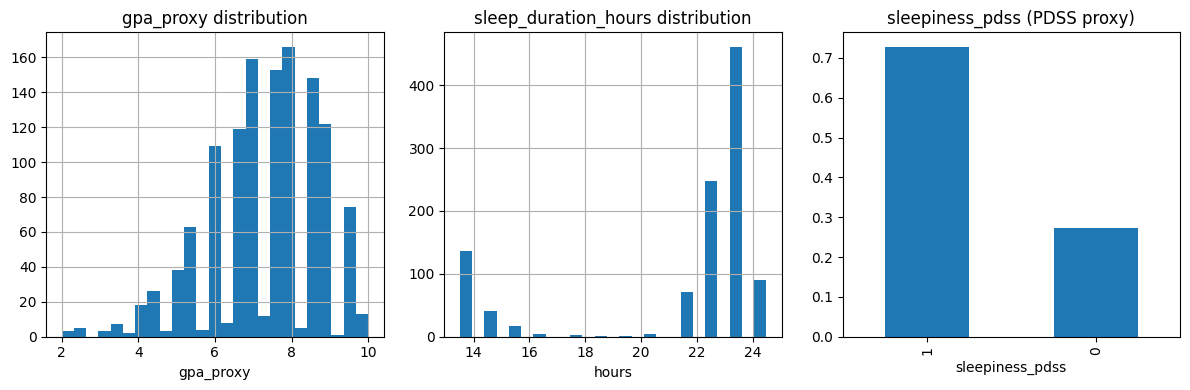

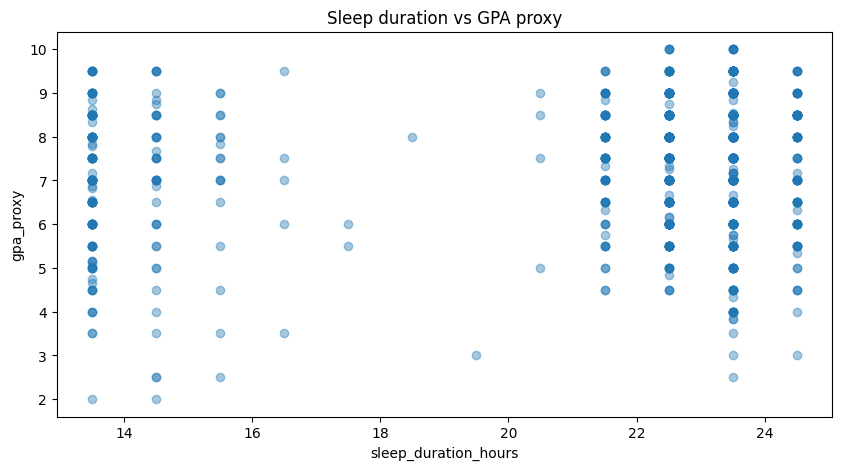

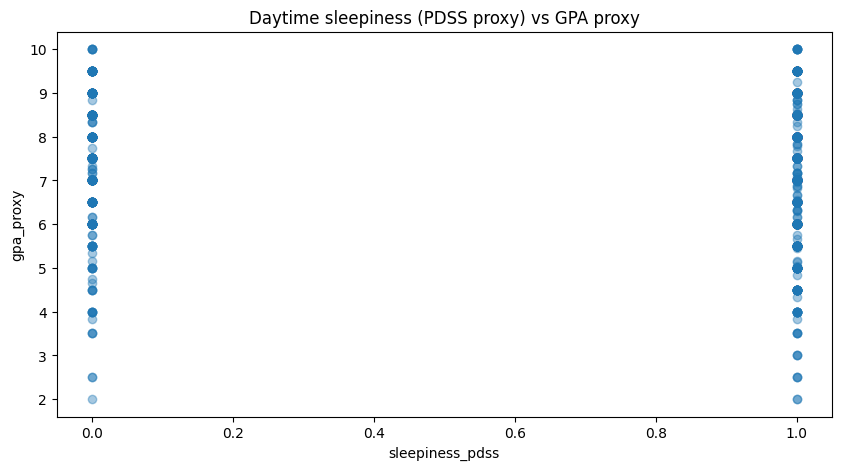

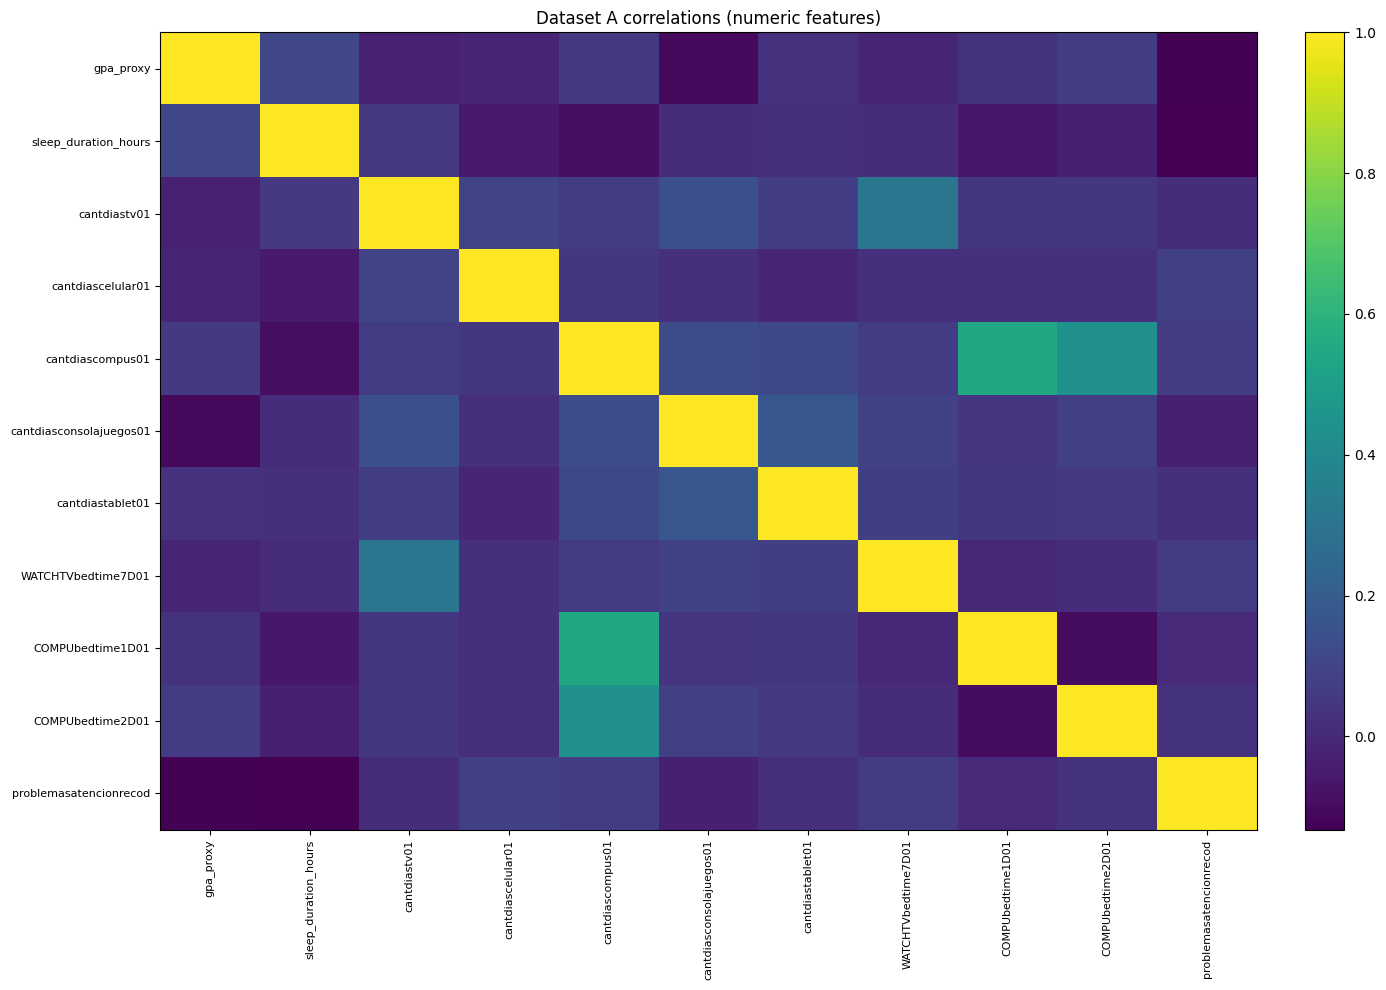

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(k) for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())])


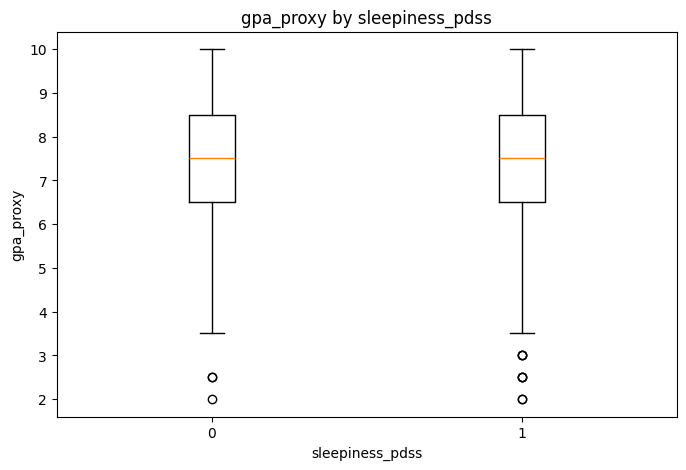

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


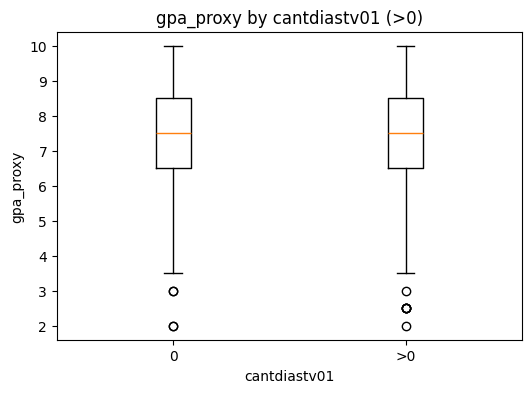

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


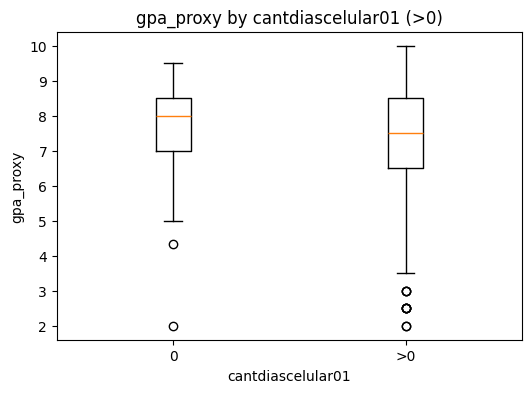

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


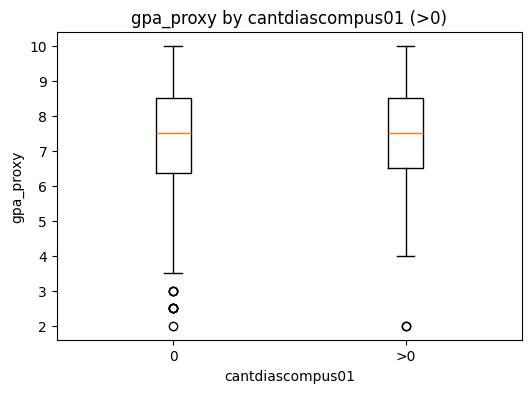

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


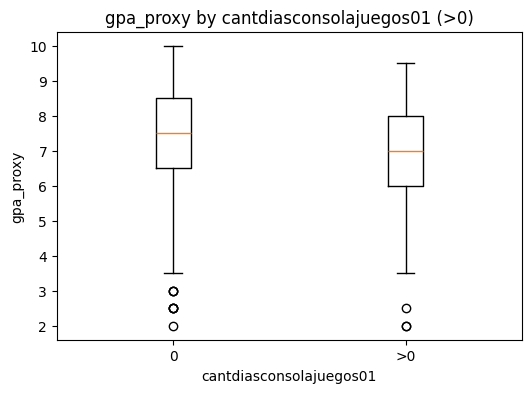

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


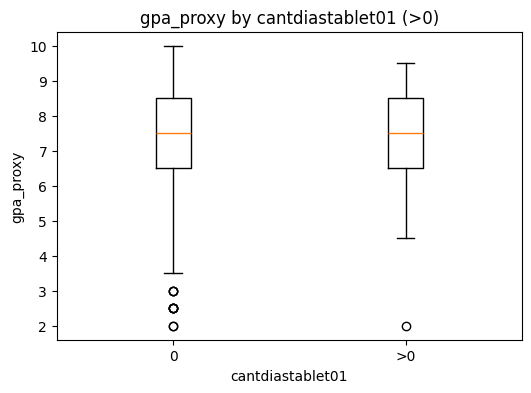

EDA complete for Dataset A


In [17]:
import matplotlib.pyplot as plt

# Guard: ensure wrangling ran
if 'A_model_df' not in globals():
    raise RuntimeError("A_model_df not found. Run Dataset A wrangling cell first.")

# Feature lists (from Dataset A wrangling)
screen_cols = [c for c in globals().get('A_screen_features', []) if c in A_model_df.columns]
sleep_cols = [c for c in globals().get('A_sleep_covariates', []) if c in A_model_df.columns]
behavior_cols = [c for c in globals().get('A_behavior_features', []) if c in A_model_df.columns]

print('EDA inputs')
print('  screen_cols:', screen_cols)
print('  sleep_cols:', sleep_cols)
print('  behavior_cols:', behavior_cols)

# -----------------------
# Summary tables
# -----------------------
summary_cols = ['gpa_proxy', 'sleep_duration_hours', 'sleepiness_pdss'] + screen_cols + behavior_cols
available_summary_cols = [c for c in summary_cols if c in A_model_df.columns]

print("\nMissingness (top) on available columns")
miss = A_model_df[available_summary_cols].isna().mean().sort_values(ascending=False)
print(miss.head(10))

print("\nGroup means by sleepiness_pdss")
group_sleep = A_model_df.groupby('sleepiness_pdss')[[
    'gpa_proxy', 'sleep_duration_hours'
]].mean(numeric_only=True)
print(group_sleep)

print("\nGroup means by screen_any (if available)")
# Define a simple screen_any proxy from day-count features if possible
screen_day_features = [c for c in screen_cols if c.startswith('cantdias')]
if screen_day_features:
    A_model_df['screen_any'] = (A_model_df[screen_day_features].fillna(0).sum(axis=1) > 0).astype(int)
    print(A_model_df.groupby('screen_any')[['gpa_proxy','sleep_duration_hours','sleepiness_pdss']].mean(numeric_only=True))
else:
    print('No screen day-count columns available; skipping screen_any.')

# -----------------------
# Distributions
# -----------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
A_model_df['gpa_proxy'].hist(bins=25)
plt.title('gpa_proxy distribution')
plt.xlabel('gpa_proxy')

plt.subplot(1, 3, 2)
A_model_df['sleep_duration_hours'].hist(bins=25)
plt.title('sleep_duration_hours distribution')
plt.xlabel('hours')

plt.subplot(1, 3, 3)
A_model_df['sleepiness_pdss'].value_counts(normalize=True).plot(kind='bar')
plt.title('sleepiness_pdss (PDSS proxy)')
plt.xlabel('sleepiness_pdss')

plt.tight_layout()
plt.show()

# -----------------------
# Relationship plots
# -----------------------
plt.figure(figsize=(10, 5))
plt.scatter(A_model_df['sleep_duration_hours'], A_model_df['gpa_proxy'], alpha=0.4)
plt.title('Sleep duration vs GPA proxy')
plt.xlabel('sleep_duration_hours')
plt.ylabel('gpa_proxy')
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(A_model_df['sleepiness_pdss'], A_model_df['gpa_proxy'], alpha=0.4)
plt.title('Daytime sleepiness (PDSS proxy) vs GPA proxy')
plt.xlabel('sleepiness_pdss')
plt.ylabel('gpa_proxy')
plt.show()

# -----------------------
# Correlation heatmap
# -----------------------
# Keep only numeric columns for correlations
corr_feature_candidates = ['gpa_proxy'] + sleep_cols + screen_cols + behavior_cols
corr_feature_candidates = [c for c in corr_feature_candidates if c in A_model_df.columns]

corr_df = A_model_df[corr_feature_candidates].copy()
# Convert constant columns to NaN correlations
corr = corr_df.corr(numeric_only=True)

# Drop rows/cols that are entirely NaN (e.g., constants)
mask_all_nan = corr.isna().all(axis=1) | corr.isna().all(axis=0)
if mask_all_nan.any():
    corr = corr.loc[~mask_all_nan, ~mask_all_nan]

plt.figure(figsize=(14, 10))
plt.imshow(corr.values, aspect='auto', interpolation='nearest')
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.index)), corr.index, fontsize=8)
plt.title('Dataset A correlations (numeric features)')
plt.tight_layout()
plt.show()

# -----------------------
# Stratified comparisons
# -----------------------
# Boxplot GPA by sleepiness
plt.figure(figsize=(8, 5))
vals = [A_model_df.loc[A_model_df['sleepiness_pdss'] == k, 'gpa_proxy'] for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())]
plt.boxplot(vals, labels=[str(k) for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())])
plt.title('gpa_proxy by sleepiness_pdss')
plt.xlabel('sleepiness_pdss')
plt.ylabel('gpa_proxy')
plt.show()

# Boxplot GPA by each screen day-count (binarized)
for c in screen_day_features[:5]:
    # Convert to binary (any usage days)
    tmp = (A_model_df[c].fillna(0) > 0).astype(int)
    plt.figure(figsize=(6, 4))
    vals = [A_model_df.loc[tmp == k, 'gpa_proxy'] for k in [0,1]]
    plt.boxplot(vals, labels=['0','>0'])
    plt.title(f'gpa_proxy by {c} (>0)')
    plt.xlabel(c)
    plt.ylabel('gpa_proxy')
    plt.show()

print('EDA complete for Dataset A')


## A.4 Inference / Mediation-Style Workflow (Dataset A)

### Goal
Estimate whether **screen-use patterns** (exposure `X`) are associated with the academic outcome (**`gpa_proxy`**, outcome `Y`), and whether that relationship is **mediated by sleep characteristics** (mediator `M`).

This implements a **mediation-style linear workflow** using multivariable regression and reports uncertainty via both:
- **Bootstrap CIs** for path coefficients and indirect effects
- **Permutation testing** (randomized exposure) to gauge how unusual the indirect effect is under a null association structure

### Model (linear mediation-style)
For a chosen mediator `M` (sleep feature):

1. **Mediator model**:  `M = a * X + Cov + e`
2. **Outcome model**:   `Y = c' * X + b * M + Cov + u`

Derived effects:
- **Direct effect**: `c'`
- **Total effect**: `c` (from `Y = c * X + Cov`)
- **Indirect (mediated) effect**: `a*b`

### What we use as `X`, `M`, and covariates
- `X` (screen exposure) is a **composite index** built from Dataset A screen-use features (`A_screen_features`) and standardized to **1 SD** within the analysis sample.
- We run mediation **separately** for two sleep constructs:
  - Mediator 1: `sleepiness_pdss`, controlling for `sleep_duration_hours`
  - Mediator 2: `sleep_duration_hours`, controlling for `sleepiness_pdss`
- Optional covariate(s): Dataset A behavioral proxy `problemasatencionrecod` when available.

### Diagnostics included in the code cell
- Residual plots and Q-Q plots for mediator + outcome regressions
- Multicollinearity check via **VIF** for predictors in the outcome model

### Interpretation checklist (read after running)
- If the **bootstrap CI** for the indirect effect `a*b` excludes 0, that supports a mediated *association* between screen-use and GPA via sleep.
- The **permutation p-value** summarizes how often a similarly large indirect effect occurs under a randomized exposure null.
- Because the dataset is effectively cross-sectional/self-report, interpret results as **mediation-style evidence**, not definitive causal mediation, unless assumptions about timing and confounding are satisfied.


Dataset A mediation run: M='sleepiness_pdss', Cov=['problemasatencionrecod', 'sleep_duration_hours']
Complete-case n=1078
Path estimates: a (X->M)=-0.0033, b (M->Y|X)=0.0231
Effects: indirect=a*b=-0.0001, direct c'=0.0144, total c=0.0143
VIF (outcome model predictors):
problemasatencionrecod    1.286469
M                         1.267421
sleep_duration_hours      1.018484
X_std                     1.004642


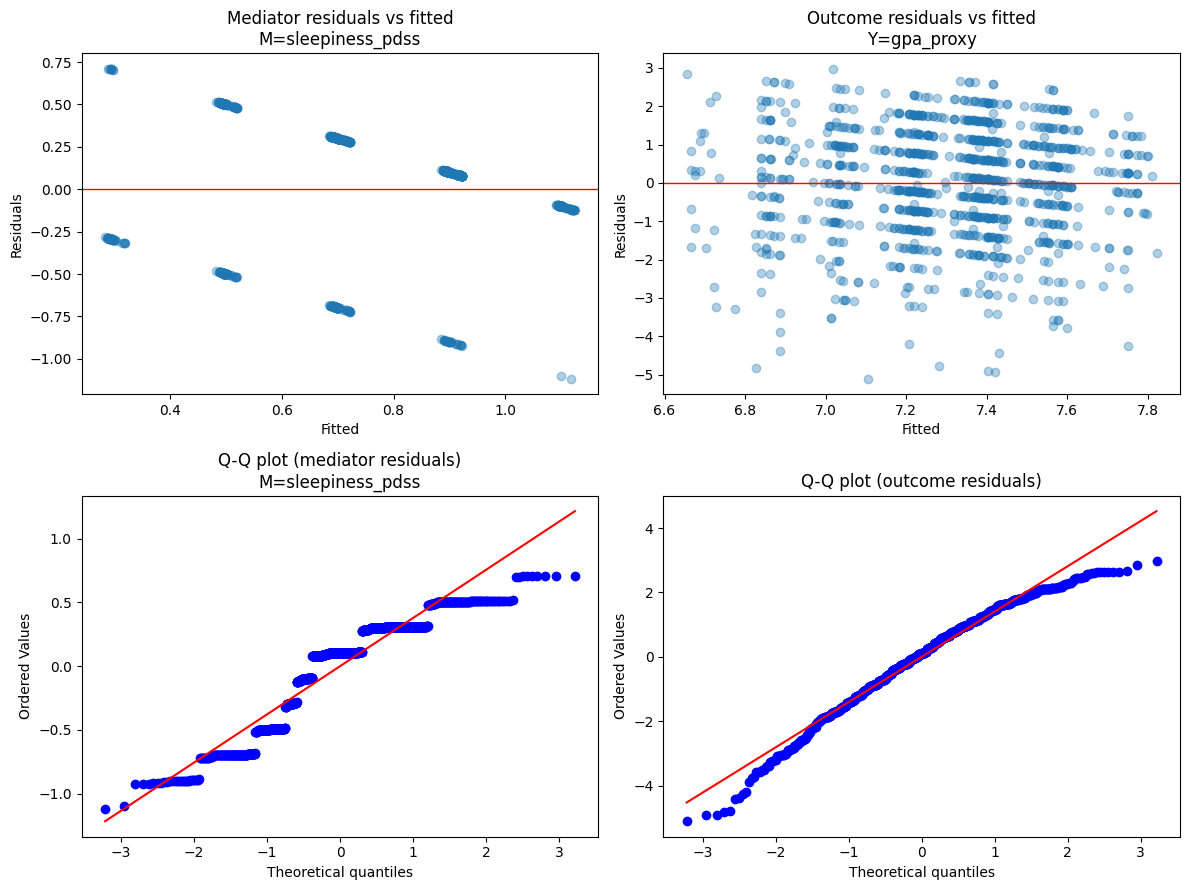


Dataset A mediation run: M='sleep_duration_hours', Cov=['problemasatencionrecod', 'sleepiness_pdss']
Complete-case n=1078
Path estimates: a (X->M)=-0.0531, b (M->Y|X)=0.0367
Effects: indirect=a*b=-0.0020, direct c'=0.0144, total c=0.0124
VIF (outcome model predictors):
problemasatencionrecod    1.286469
sleepiness_pdss           1.267421
M                         1.018484
X_std                     1.004642


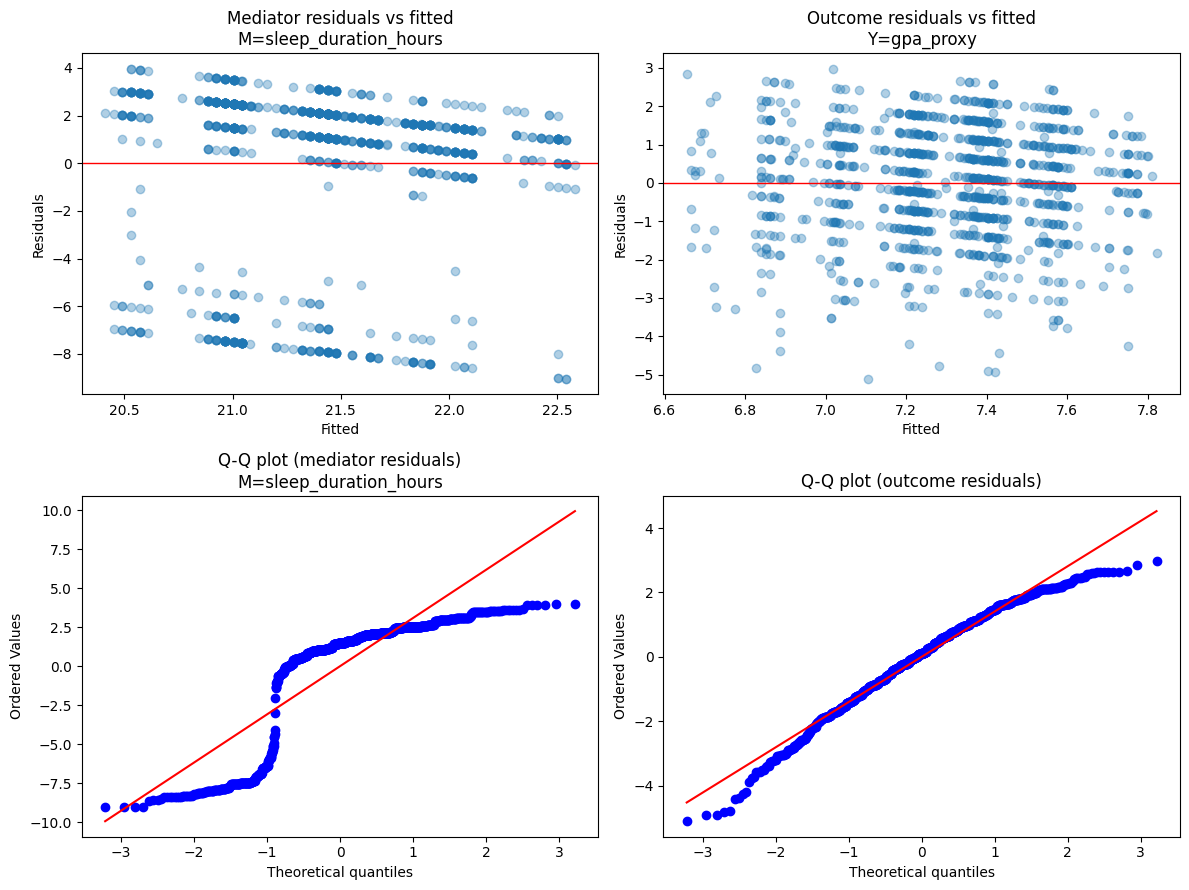


Dataset A mediation summary (screen -> sleep -> GPA proxy)
            mediator  n_complete_cases     a_hat  a_ci_low  a_ci_high    b_hat  b_ci_low  b_ci_high  c_prime_hat  c_prime_ci_low  c_prime_ci_high  c_total_hat  c_total_ci_low  c_total_ci_high  indirect_hat  indirect_ci_low  indirect_ci_high  perm_p_value  boot_succ  perm_succ                        covariates_in_models
sleep_duration_hours              1078 -0.053104 -0.297792   0.172410 0.036735  0.010409   0.064423     0.014374       -0.065821         0.084679     0.012424       -0.067567         0.085847     -0.001951        -0.010975          0.006004      0.643564        300        100      problemasatencionrecod,sleepiness_pdss
     sleepiness_pdss              1078 -0.003272 -0.029674   0.021527 0.023143 -0.191890   0.204963     0.014374       -0.073391         0.096389     0.014299       -0.071998         0.096109     -0.000076        -0.003781          0.002917      0.851485        300        100 problemasatencionreco

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels is preferred; if unavailable, fall back to a lightweight numpy-based OLS
try:
    import statsmodels.api as sm  # type: ignore
except ModuleNotFoundError:
    from scipy import stats as _scipy_stats

    def _add_constant(X, has_constant: str = 'add'):
        """Minimal replacement for statsmodels.api.add_constant."""
        if isinstance(X, pd.DataFrame):
            if 'const' in X.columns:
                return X
            out = X.copy()
            out.insert(0, 'const', 1.0)
            return out
        X_arr = np.asarray(X, dtype=float)
        ones = np.ones((X_arr.shape[0], 1), dtype=float)
        return np.hstack([ones, X_arr])

    class _OLSResult:
        def __init__(self, params, fittedvalues, resid, rsquared):
            self.params = params
            self.fittedvalues = fittedvalues
            self.resid = resid
            self.rsquared = rsquared

    class _OLSModel:
        def __init__(self, endog, exog):
            self.endog = np.asarray(endog, dtype=float)
            self.exog_is_df = isinstance(exog, pd.DataFrame)
            self.exog_df = exog if self.exog_is_df else None
            self.exog_mat = exog.values.astype(float) if self.exog_is_df else np.asarray(exog, dtype=float)
            self.param_names = list(self.exog_df.columns) if self.exog_is_df else None

        def fit(self):
            beta = np.linalg.lstsq(self.exog_mat, self.endog, rcond=None)[0]
            fitted = self.exog_mat @ beta
            resid = self.endog - fitted
            ss_res = float(np.sum(resid ** 2))
            y = self.endog
            ss_tot = float(np.sum((y - y.mean()) ** 2))
            rsq = (1.0 - ss_res / ss_tot) if ss_tot != 0 else 0.0
            params = pd.Series(beta, index=self.param_names) if self.param_names is not None else beta
            return _OLSResult(params=params, fittedvalues=fitted, resid=resid, rsquared=rsq)

    def _OLS(endog, exog):
        return _OLSModel(endog=endog, exog=exog)

    def _qqplot(x, line: str = '45', ax=None):
        if ax is None:
            ax = plt.gca()
        _scipy_stats.probplot(x, dist='norm', plot=ax)
        return ax

    class _SMWrapper:
        add_constant = staticmethod(_add_constant)
        OLS = staticmethod(_OLS)
        qqplot = staticmethod(_qqplot)

    sm = _SMWrapper()

# -----------------------
# Parameters (adjust if runtime is too slow)
# -----------------------
N_BOOT = 300
N_PERM = 100
SEED = 42

# Guard: ensure wrangling ran
if 'A_model_df' not in globals():
    raise RuntimeError("A_model_df not found. Run Dataset A wrangling cell first.")

# -----------------------
# Exposure / feature definitions
# -----------------------
Y_COL = 'gpa_proxy'

screen_features = [c for c in globals().get('A_screen_features', []) if c in A_model_df.columns]
if not screen_features:
    raise RuntimeError("No screen features found in globals(). Expected A_screen_features from Dataset A wrangling.")

behavior_features = [c for c in globals().get('A_behavior_features', []) if c in A_model_df.columns]

BASE_DF = A_model_df.copy()

# Screen exposure composite (sum across features); missing screen values are treated as 0.
BASE_DF['screen_exposure_raw'] = BASE_DF[screen_features].fillna(0).sum(axis=1)

# Optional covariate(s)
COV_BASE = []
for c in behavior_features:
    if c not in COV_BASE:
        COV_BASE.append(c)

# Two sleep mediators; we run them separately for interpretability.
MEDIATOR_SPECS = [
    ('sleepiness_pdss', 'sleep_duration_hours'),  # M, covariate
    ('sleep_duration_hours', 'sleepiness_pdss'),  # M, covariate
]


def _standardize_1sd(x: pd.Series) -> pd.Series:
    """Standardize to mean=0, sd=1 (within a given analysis sample)."""
    x = pd.to_numeric(x, errors='coerce')
    sd = x.std(ddof=0)
    if sd is None or sd == 0 or np.isnan(sd):
        return x * 0.0
    return (x - x.mean()) / sd


def _fit_ols_models(df_work: pd.DataFrame, mediator_col: str, cov_cols: list[str]):
    """Fit: M~X+Cov and Y~X+M+Cov (X is standardized internally)."""
    df_work = df_work.dropna(subset=[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols).copy()

    # Standardize X within the (already complete-case) analysis sample
    df_work['X_std'] = _standardize_1sd(df_work['screen_exposure_raw'])

    y = df_work[Y_COL].astype(float).values
    m = df_work[mediator_col].astype(float).values

    # Mediator model: M ~ X + Cov
    X_m = pd.DataFrame({'x': df_work['X_std'].values})
    for c in cov_cols:
        X_m[c] = df_work[c].values
    X_m = sm.add_constant(X_m, has_constant='add')
    model_m = sm.OLS(m, X_m).fit()
    a = float(model_m.params['x'])

    # Outcome model: Y ~ X + M + Cov
    X_y = pd.DataFrame({'x': df_work['X_std'].values, 'm': m})
    for c in cov_cols:
        X_y[c] = df_work[c].values
    X_y = sm.add_constant(X_y, has_constant='add')
    model_y = sm.OLS(y, X_y).fit()
    b = float(model_y.params['m'])
    c_prime = float(model_y.params['x'])

    # Total effect model: Y ~ X + Cov
    X_t = pd.DataFrame({'x': df_work['X_std'].values})
    for c in cov_cols:
        X_t[c] = df_work[c].values
    X_t = sm.add_constant(X_t, has_constant='add')
    model_t = sm.OLS(y, X_t).fit()
    c_total = float(model_t.params['x'])

    indirect = a * b

    return {
        'n': int(df_work.shape[0]),
        'a': a,
        'b': b,
        'c_prime': c_prime,
        'c_total': c_total,
        'indirect': indirect,
        'model_m': model_m,
        'model_y': model_y,
        'model_t': model_t,
        'df_work': df_work,
    }


def _vif(df_design: pd.DataFrame) -> pd.Series:
    """Variance Inflation Factor for numeric predictors (no constant required)."""
    # df_design: columns are predictors
    from numpy.linalg import LinAlgError

    vifs = {}
    for col in df_design.columns:
        y = df_design[col].astype(float).values
        X = df_design.drop(columns=[col]).astype(float)
        if X.shape[1] == 0:
            vifs[col] = np.nan
            continue
        try:
            r2 = sm.OLS(y, sm.add_constant(X, has_constant='add')).fit().rsquared
            vifs[col] = float(1.0 / (1.0 - r2)) if (1.0 - r2) != 0 else np.inf
        except LinAlgError:
            vifs[col] = np.inf
    return pd.Series(vifs)


def _compute_effects(df_sample: pd.DataFrame, mediator_col: str, cov_cols: list[str]):
    """Compute (a, b, c_prime, c_total, indirect) for one dataset draw."""
    df_sample = df_sample.dropna(subset=[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols).copy()
    if df_sample.shape[0] < 30:
        return None

    df_sample['X_std'] = _standardize_1sd(df_sample['screen_exposure_raw'])

    y = df_sample[Y_COL].astype(float).values
    m = df_sample[mediator_col].astype(float).values

    # M ~ X + Cov
    X_m = pd.DataFrame({'x': df_sample['X_std'].values})
    for c in cov_cols:
        X_m[c] = df_sample[c].values
    X_m = sm.add_constant(X_m, has_constant='add')
    model_m = sm.OLS(m, X_m).fit()
    a = float(model_m.params['x'])

    # Y ~ X + M + Cov
    X_y = pd.DataFrame({'x': df_sample['X_std'].values, 'm': m})
    for c in cov_cols:
        X_y[c] = df_sample[c].values
    X_y = sm.add_constant(X_y, has_constant='add')
    model_y = sm.OLS(y, X_y).fit()
    b = float(model_y.params['m'])
    c_prime = float(model_y.params['x'])

    # Y ~ X + Cov
    X_t = pd.DataFrame({'x': df_sample['X_std'].values})
    for c in cov_cols:
        X_t[c] = df_sample[c].values
    X_t = sm.add_constant(X_t, has_constant='add')
    model_t = sm.OLS(y, X_t).fit()
    c_total = float(model_t.params['x'])

    indirect = a * b

    return a, b, c_prime, c_total, indirect


rng = np.random.default_rng(SEED)
results_rows = []

for mediator_col, other_sleep_cov in MEDIATOR_SPECS:
    if mediator_col not in BASE_DF.columns:
        print(f"Skipping mediator '{mediator_col}': missing column")
        continue

    cov_cols = list(COV_BASE)
    if other_sleep_cov in BASE_DF.columns:
        # Include the other sleep construct as a covariate so we can interpret M separately.
        cov_cols = cov_cols + [other_sleep_cov]

    # Complete-case base for this mediation run
    base_df = BASE_DF[[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols].dropna().copy()
    n = int(base_df.shape[0])
    if n < 100:
        print(f"WARNING: mediation run for mediator='{mediator_col}' has small n={n} complete cases.")

    # Observed fits + diagnostics
    observed = _fit_ols_models(base_df, mediator_col=mediator_col, cov_cols=cov_cols)

    # VIF on outcome-model predictors (X_std, M, plus Cov)
    dfv = observed['df_work'].copy()
    dfv['X_std'] = _standardize_1sd(dfv['screen_exposure_raw'])
    design_out = pd.DataFrame({'X_std': dfv['X_std'].values, 'M': dfv[mediator_col].astype(float).values})
    for c in cov_cols:
        design_out[c] = dfv[c].values
    vif = _vif(design_out)

    print("\n" + "="*80)
    print(f"Dataset A mediation run: M='{mediator_col}', Cov={cov_cols}")
    print(f"Complete-case n={observed['n']}")
    print(f"Path estimates: a (X->M)={observed['a']:.4f}, b (M->Y|X)={observed['b']:.4f}")
    print(f"Effects: indirect=a*b={observed['indirect']:.4f}, direct c'={observed['c_prime']:.4f}, total c={observed['c_total']:.4f}")
    print("VIF (outcome model predictors):")
    print(vif.sort_values(ascending=False).to_string())

    # Bootstrap uncertainty
    boot_effects = []
    boot_indirect = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        sample_df = base_df.iloc[idx]
        eff = _compute_effects(sample_df, mediator_col=mediator_col, cov_cols=cov_cols)
        if eff is None:
            continue
        a, b, c_prime, c_total, indirect = eff
        boot_effects.append((a, b, c_prime, c_total, indirect))
        boot_indirect.append(indirect)

    boot_effects = np.array(boot_effects, dtype=float)
    if boot_effects.shape[0] < max(50, N_BOOT * 0.5):
        print(f"WARNING: bootstrap draws succeeded={boot_effects.shape[0]} / {N_BOOT} for mediator='{mediator_col}'")

    def _ci(x: np.ndarray, alpha: float = 0.05):
        lo = np.nanpercentile(x, 100 * (alpha/2))
        hi = np.nanpercentile(x, 100 * (1 - alpha/2))
        return float(lo), float(hi)

    a_boot = boot_effects[:, 0]
    b_boot = boot_effects[:, 1]
    c_prime_boot = boot_effects[:, 2]
    c_total_boot = boot_effects[:, 3]
    indirect_boot = boot_effects[:, 4]

    a_ci = _ci(a_boot)
    b_ci = _ci(b_boot)
    c_prime_ci = _ci(c_prime_boot)
    c_total_ci = _ci(c_total_boot)
    indirect_ci = _ci(indirect_boot)

    # Permutation null for indirect effect
    perm_indirect = []
    x_values = base_df['screen_exposure_raw'].astype(float).values
    for _ in range(N_PERM):
        perm_x = rng.permutation(x_values)
        perm_df = base_df.copy()
        perm_df['screen_exposure_raw'] = perm_x
        eff = _compute_effects(perm_df, mediator_col=mediator_col, cov_cols=cov_cols)
        if eff is None:
            continue
        perm_indirect.append(eff[-1])

    perm_indirect = np.array(perm_indirect, dtype=float)
    # Two-sided permutation p-value using absolute magnitude
    p_perm = (np.sum(np.abs(perm_indirect) >= abs(observed['indirect'])) + 1) / (len(perm_indirect) + 1)

    results_rows.append({
        'mediator': mediator_col,
        'n_complete_cases': observed['n'],
        'a_hat': observed['a'],
        'a_ci_low': a_ci[0],
        'a_ci_high': a_ci[1],
        'b_hat': observed['b'],
        'b_ci_low': b_ci[0],
        'b_ci_high': b_ci[1],
        'c_prime_hat': observed['c_prime'],
        'c_prime_ci_low': c_prime_ci[0],
        'c_prime_ci_high': c_prime_ci[1],
        'c_total_hat': observed['c_total'],
        'c_total_ci_low': c_total_ci[0],
        'c_total_ci_high': c_total_ci[1],
        'indirect_hat': observed['indirect'],
        'indirect_ci_low': indirect_ci[0],
        'indirect_ci_high': indirect_ci[1],
        'perm_p_value': p_perm,
        'boot_succ': int(boot_effects.shape[0]),
        'perm_succ': int(perm_indirect.shape[0]),
        'covariates_in_models': ','.join(cov_cols),
    })

    # -----------------------
    # Diagnostics plots (observed sample)
    # -----------------------
    model_m = observed['model_m']
    model_y = observed['model_y']

    # Mediator residuals
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # Residuals vs fitted (mediator)
    axes[0, 0].scatter(model_m.fittedvalues, model_m.resid, alpha=0.35)
    axes[0, 0].axhline(0, color='red', linewidth=1)
    axes[0, 0].set_title(f"Mediator residuals vs fitted\nM={mediator_col}")
    axes[0, 0].set_xlabel('Fitted')
    axes[0, 0].set_ylabel('Residuals')

    # Residuals vs fitted (outcome)
    axes[0, 1].scatter(model_y.fittedvalues, model_y.resid, alpha=0.35)
    axes[0, 1].axhline(0, color='red', linewidth=1)
    axes[0, 1].set_title(f"Outcome residuals vs fitted\nY=gpa_proxy")
    axes[0, 1].set_xlabel('Fitted')
    axes[0, 1].set_ylabel('Residuals')

    # Q-Q plot (mediator residuals)
    sm.qqplot(model_m.resid, line='45', ax=axes[1, 0])
    axes[1, 0].set_title(f"Q-Q plot (mediator residuals)\nM={mediator_col}")

    # Q-Q plot (outcome residuals)
    sm.qqplot(model_y.resid, line='45', ax=axes[1, 1])
    axes[1, 1].set_title("Q-Q plot (outcome residuals)")

    plt.tight_layout()
    plt.show()


A_mediation_results = pd.DataFrame(results_rows)
A_mediation_results = A_mediation_results.sort_values('mediator')

print("\n" + "="*80)
print("Dataset A mediation summary (screen -> sleep -> GPA proxy)")
print(A_mediation_results.to_string(index=False))

# Keep results in notebook globals for later comparison/plots
A_mediation_results_df = A_mediation_results


## How to read the Dataset A mediation output

After running the workflow cell, focus on the table printed as `Dataset A mediation summary (screen -> sleep -> GPA proxy)`:

- `indirect_hat` is the **estimated mediated (indirect) association** `a*b`.
- `indirect_ci_low` / `indirect_ci_high` is the **bootstrap 95% CI** for the indirect effect.
- `perm_p_value` is a **permutation p-value** based on how often an indirect effect of equal-or-greater magnitude appears after randomizing the exposure (`X`).

Residual plots + Q-Q plots are diagnostic checks for whether linear model residuals look approximately well-behaved; VIF helps flag multicollinearity among predictors in the outcome regression.

If you want to strengthen robustness in the next iteration, we can (a) add more covariates, (b) define alternative screen-exposure composites, and/or (c) increase `N_BOOT` / `N_PERM`.

## A.5 Prediction & Feature-Group Ablations (RQ3) (Dataset A)

Goal: predict the **GPA proxy** (`gpa_proxy`) from Dataset A features using supervised ML with:
- **Cross-validation** performance estimates
- **Baselines** (mean/OLS)
- **Regularized models** (RidgeCV and ElasticNetCV)
- **Feature-group ablations** comparing `screen-only` vs `sleep-only` vs `combined`
- **Interpretability** via (a) linear coefficient magnitude and (b) permutation feature importance

Outputs (dataframes) produced by the code cell:
- `A_ml_cv_summary` (CV metrics by model and feature group)
- `A_ml_oof_predictions` (out-of-fold predictions for the chosen best model on the combined feature set)
- `A_ml_feature_importance` (top features for the best combined regularized model)


Evaluating feature group: screen_only (n_features=8)
               model   r2_mean  rmse_mean
       ridge_ridgecv  0.007244   1.428673
                 ols  0.005909   1.429616
elastic_elasticnetcv  0.005083   1.430207
       baseline_mean -0.002999   1.435832

Evaluating feature group: sleep_only (n_features=2)
               model   r2_mean  rmse_mean
       ridge_ridgecv  0.006379   1.429538
                 ols  0.006224   1.429690
elastic_elasticnetcv  0.000693   1.433441
       baseline_mean -0.002999   1.435832

Evaluating feature group: combined (n_features=11)
               model   r2_mean  rmse_mean
       ridge_ridgecv  0.032340   1.411082
                 ols  0.031115   1.411977
elastic_elasticnetcv  0.028701   1.413619
       baseline_mean -0.002999   1.435832

Dataset A supervised prediction summary (CV)
feature_group                model  n_features  rmse_mean  rmse_std  mae_mean   r2_mean   r2_std
     combined        ridge_ridgecv          11   1.411082  0.123962 

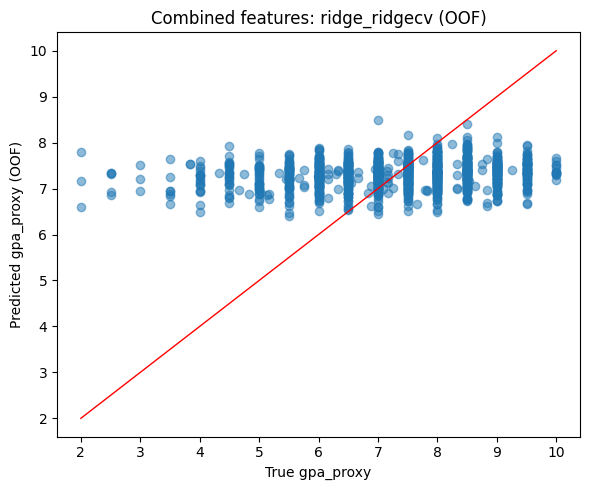


Top feature importance (combined, best regularized model):
                feature      coef  abs_coef  perm_importance_mean  perm_importance_std
 problemasatencionrecod -0.177203  0.177203              0.031765             0.006959
cantdiasconsolajuegos01 -0.163226  0.163226              0.024782             0.004157
   sleep_duration_hours  0.123385  0.123385              0.016674             0.004073
       COMPUbedtime2D01  0.077371  0.077371              0.006330             0.002735
       cantdiascompus01  0.066548  0.066548              0.004897             0.002209
       cantdiastablet01  0.055982  0.055982              0.003484             0.000899
           cantdiastv01 -0.035125  0.035125              0.001065             0.001015
       COMPUbedtime1D01  0.034116  0.034116              0.001136             0.001097
        sleepiness_pdss  0.021125  0.021125              0.000389             0.001078
     WATCHTVbedtime7D01  0.004877  0.004877              0.000087     

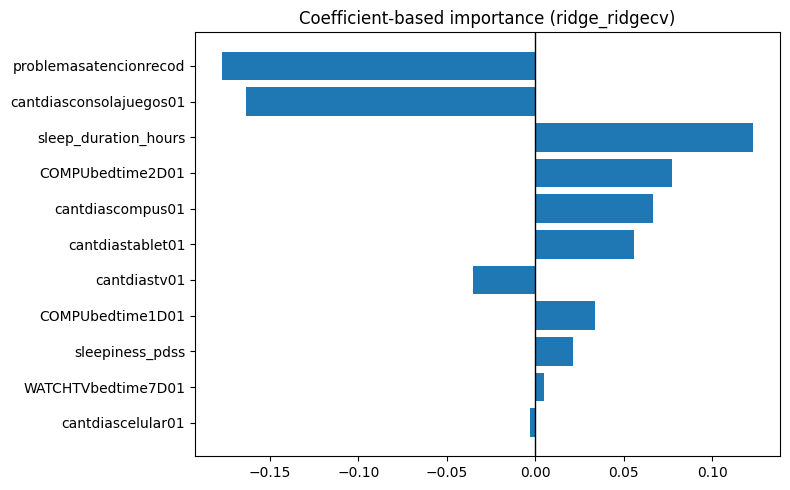

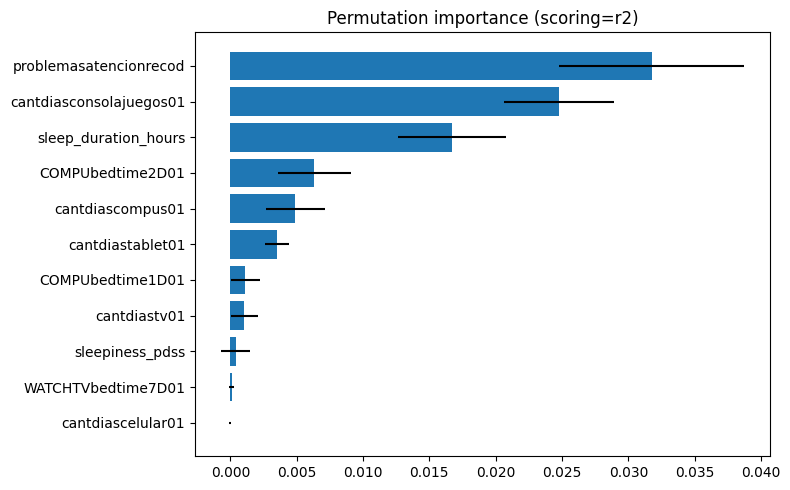

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

SEED = 42
N_SPLITS = 5

# Guard: ensure Dataset A wrangling ran
if 'A_model_df' not in globals():
    raise RuntimeError("A_model_df not found. Run Dataset A wrangling cell first.")

Y_COL = 'gpa_proxy'

df_ml = A_model_df.copy()
if Y_COL not in df_ml.columns:
    raise RuntimeError(f"Missing target '{Y_COL}' in A_model_df")

df_ml = df_ml.dropna(subset=[Y_COL]).copy()

# Feature groups
screen_features = [c for c in globals().get('A_screen_features', []) if c in df_ml.columns]
sleep_features = [c for c in ['sleep_duration_hours', 'sleepiness_pdss'] if c in df_ml.columns]
behavior_features = [c for c in globals().get('A_behavior_features', []) if c in df_ml.columns]

combined_features = list(dict.fromkeys(screen_features + sleep_features + behavior_features))

feature_groups = {
    'screen_only': screen_features,
    'sleep_only': sleep_features,
    'combined': combined_features,
}

# Sanity checks
for k, cols in feature_groups.items():
    if len(cols) == 0:
        raise RuntimeError(f"Feature group '{k}' has no columns. Check Dataset A wrangling.")

# CV folds (shared across ablations for fair comparison)
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(kf.split(df_ml))


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_group(group_name: str, cols: list[str]):
    X = df_ml[cols]
    y = df_ml[Y_COL].astype(float).values

    # Pipelines
    ridge_alphas = np.logspace(-2, 2, 9)  # 0.01 ... 100
    elastic_alphas = np.logspace(-3, 0, 7)  # 0.001 ... 1
    elastic_l1_ratios = [0.1, 0.5, 0.9]

    def make_dummy():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', DummyRegressor(strategy='mean')),
        ])

    def make_ols():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', LinearRegression()),
        ])

    def make_ridge():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', RidgeCV(alphas=ridge_alphas, cv=5)),
        ])

    def make_elastic():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', ElasticNetCV(alphas=elastic_alphas, l1_ratio=elastic_l1_ratios, cv=5, max_iter=100000, random_state=SEED)),
        ])

    model_builders = {
        'baseline_mean': make_dummy,
        'ols': make_ols,
        'ridge_ridgecv': make_ridge,
        'elastic_elasticnetcv': make_elastic,
    }

    results = []
    # Store out-of-fold predictions for the combined group later for the best model
    oof_preds_by_model = {name: np.full_like(y, fill_value=np.nan, dtype=float) for name in model_builders}

    for model_name, make_model in model_builders.items():
        fold_rmses, fold_maes, fold_r2s = [], [], []

        for fold_i, (train_idx, test_idx) in enumerate(folds):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = make_model()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            oof_preds_by_model[model_name][test_idx] = y_pred

            fold_rmses.append(rmse(y_test, y_pred))
            fold_maes.append(float(mean_absolute_error(y_test, y_pred)))
            fold_r2s.append(float(r2_score(y_test, y_pred)))

        results.append({
            'feature_group': group_name,
            'model': model_name,
            'n_features': int(len(cols)),
            'rmse_mean': float(np.mean(fold_rmses)),
            'rmse_std': float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0,
            'mae_mean': float(np.mean(fold_maes)),
            'r2_mean': float(np.mean(fold_r2s)),
            'r2_std': float(np.std(fold_r2s, ddof=1)) if len(fold_r2s) > 1 else 0.0,
        })

    results_df = pd.DataFrame(results).sort_values('r2_mean', ascending=False)
    return results_df, oof_preds_by_model, X, y


all_rows = []
oof_predictions_store = {}
X_store = {}
y_store = {}

for group_name, cols in feature_groups.items():
    print(f"\nEvaluating feature group: {group_name} (n_features={len(cols)})")
    res_df, oof_preds_by_model, X, y = evaluate_group(group_name, cols)
    print(res_df[['model', 'r2_mean', 'rmse_mean']].to_string(index=False))

    all_rows.append(res_df)
    oof_predictions_store[group_name] = oof_preds_by_model
    X_store[group_name] = X
    y_store[group_name] = y

A_ml_cv_summary = pd.concat(all_rows, ignore_index=True)
A_ml_cv_summary = A_ml_cv_summary.sort_values(['feature_group', 'r2_mean'], ascending=[True, False])

print("\n" + "="*80)
print("Dataset A supervised prediction summary (CV)")
print(A_ml_cv_summary.to_string(index=False))

# Choose best model on combined regularized family (ridge/elastic) for interpretability + plots
combined_summary = A_ml_cv_summary[A_ml_cv_summary['feature_group'] == 'combined']
regularized = combined_summary[combined_summary['model'].isin(['ridge_ridgecv', 'elastic_elasticnetcv'])]

if len(regularized) > 0:
    best_model_name = regularized.sort_values('r2_mean', ascending=False).iloc[0]['model']
else:
    best_model_name = combined_summary.sort_values('r2_mean', ascending=False).iloc[0]['model']

print("\nBest combined model for interpretability:", best_model_name)

# Get combined OOF predictions for the best model
X_comb = X_store['combined']
y_comb = y_store['combined']
oof_pred_comb = oof_predictions_store['combined'][best_model_name]

A_ml_oof_predictions = pd.DataFrame({
    'y_true': y_comb,
    'y_pred': oof_pred_comb,
})

# Plot: y_true vs y_pred
plt.figure(figsize=(6, 5))
plt.scatter(A_ml_oof_predictions['y_true'], A_ml_oof_predictions['y_pred'], alpha=0.5)
minv = float(min(A_ml_oof_predictions['y_true'].min(), A_ml_oof_predictions['y_pred'].min()))
maxv = float(max(A_ml_oof_predictions['y_true'].max(), A_ml_oof_predictions['y_pred'].max()))
plt.plot([minv, maxv], [minv, maxv], color='red', linewidth=1)
plt.xlabel('True gpa_proxy')
plt.ylabel('Predicted gpa_proxy (OOF)')
plt.title(f'Combined features: {best_model_name} (OOF)')
plt.tight_layout()
plt.show()

# Fit the best model on the full combined dataset for coefficient/permutation importance
cols_comb = feature_groups['combined']
X_full = X_comb

ridge_alphas = np.logspace(-2, 2, 9)
elastic_alphas = np.logspace(-3, 0, 7)
elastic_l1_ratios = [0.1, 0.5, 0.9]

if best_model_name == 'ridge_ridgecv':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=ridge_alphas, cv=5)),
    ])
elif best_model_name == 'elastic_elasticnetcv':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', ElasticNetCV(alphas=elastic_alphas, l1_ratio=elastic_l1_ratios, cv=5, max_iter=100000, random_state=SEED)),
    ])
else:
    # Fallback: OLS
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', LinearRegression()),
    ])

final_model.fit(X_full, y_comb)

# Coefficient-based feature ranking (for linear regularized models)
coef_importance_df = None
if hasattr(final_model.named_steps['model'], 'coef_'):
    coefs = final_model.named_steps['model'].coef_
    coef_importance_df = pd.DataFrame({
        'feature': cols_comb,
        'coef': coefs,
        'abs_coef': np.abs(coefs),
    }).sort_values('abs_coef', ascending=False)

# Permutation importance (agnostic)
perm_importance_df = None
try:
    perm = permutation_importance(final_model, X_full, y_comb, n_repeats=15, random_state=SEED, scoring='r2')
    perm_importance_df = pd.DataFrame({
        'feature': cols_comb,
        'perm_importance_mean': perm.importances_mean,
        'perm_importance_std': perm.importances_std,
    }).sort_values('perm_importance_mean', ascending=False)
except Exception as e:
    print("Permutation importance failed:", repr(e))

# Combine importance tables
if coef_importance_df is not None and perm_importance_df is not None:
    A_ml_feature_importance = coef_importance_df.merge(perm_importance_df, on='feature', how='left')
elif coef_importance_df is not None:
    A_ml_feature_importance = coef_importance_df
elif perm_importance_df is not None:
    A_ml_feature_importance = perm_importance_df
else:
    A_ml_feature_importance = pd.DataFrame({'feature': cols_comb})

A_ml_feature_importance = A_ml_feature_importance.reset_index(drop=True)
print("\nTop feature importance (combined, best regularized model):")
print(A_ml_feature_importance.head(15).to_string(index=False))

# Plot: top coefficient magnitudes (if available)
if coef_importance_df is not None:
    topk = min(12, len(coef_importance_df))
    plt.figure(figsize=(8, 5))
    tmp = coef_importance_df.head(topk).iloc[::-1]
    plt.barh(tmp['feature'], tmp['coef'])
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f'Coefficient-based importance ({best_model_name})')
    plt.tight_layout()
    plt.show()

# Plot: permutation importance (if available)
if perm_importance_df is not None:
    topk = min(12, len(perm_importance_df))
    plt.figure(figsize=(8, 5))
    tmp = perm_importance_df.head(topk).iloc[::-1]
    plt.barh(tmp['feature'], tmp['perm_importance_mean'], xerr=tmp['perm_importance_std'])
    plt.title('Permutation importance (scoring=r2)')
    plt.tight_layout()
    plt.show()


## How to interpret Dataset A prediction + ablation results

1. **Predictive value by feature group**: compare `r2_mean` (and RMSE) across `screen_only` vs `sleep_only` vs `combined`.
   - If `combined` is substantially better, sleep likely adds information beyond screen features (in prediction terms).

2. **Regularization sanity check**: compare `ols` vs `ridge_ridgecv` and `elastic_elasticnetcv`.
   - If Ridge/ElasticNet improves test metrics, it suggests multicollinearity/overfitting risk in this feature set.

3. **Interpretability (importance)**:
   - `coef` rankings reflect the fitted **linear regularized** model. Because we standardize features before Ridge/ElasticNet, coefficients correspond to effect per **1 SD** change in that feature (holding other included features constant).
   - `perm_importance_mean` shows how much the model `R^2` drops when a feature is randomly permuted (agnostic to linearity).

4. **Caution**: these are supervised prediction results from cross-sectional data; strong predictive weights do not automatically imply causal mediation.

## B.1 Ingestion (cohort outcome + sleepiness inputs)

This cell constructs a cohort-level Dataset B table by:
- Loading outcomes from `datasets/student-life/dataset/education/grades.csv` (by `uid`)
- Loading sleepiness/sleep survey items from `datasets/student-life/dataset/survey/psqi.csv` (choosing `post` if present)
- Loading EMA “Sleep” events from `datasets/student-life/dataset/EMA/response/Sleep/` and aggregating them into user-level sleepiness features (e.g., mean `rate`, late-night fraction)

Outputs:
- `B_grades`, `B_psqi_processed`, `B_ema_sleep_agg`, and merged `B_cohort_df`

In [20]:
import json
from pathlib import Path
import re

import numpy as np
import pandas as pd

# -----------------------
# Paths
# -----------------------
grades_path = Path('datasets/student-life/dataset/education/grades.csv')
psqi_path = Path('datasets/student-life/dataset/survey/psqi.csv')
ema_sleep_dir = Path('datasets/student-life/dataset/EMA/response/Sleep')

assert grades_path.exists(), f"Missing {grades_path}"
assert psqi_path.exists(), f"Missing {psqi_path}"
assert ema_sleep_dir.exists(), f"Missing {ema_sleep_dir}"

# -----------------------
# 1) Outcomes: grades
# -----------------------
B_grades = pd.read_csv(grades_path)
# Normalize uid column name
if 'uid' not in B_grades.columns:
    # Some CSVs sometimes name the first column differently; fall back to first column
    B_grades = B_grades.rename(columns={B_grades.columns[0]: 'uid'})

# Standardize outcome column names (trim spaces)
B_grades.columns = [str(c).strip() for c in B_grades.columns]

# Heuristic expected columns
outcome_cols = {
    'gpa all': 'gpa_all',
    'gpa 13s': 'gpa_13s',
    'cs 65': 'cs_65',
}
for src, dst in outcome_cols.items():
    if src in B_grades.columns:
        B_grades = B_grades.rename(columns={src: dst})

required_outcomes = [v for v in outcome_cols.values() if v in B_grades.columns]
if len(required_outcomes) == 0:
    raise RuntimeError(f"Could not find expected outcome columns in {grades_path}. Found columns={list(B_grades.columns)}")

# Ensure uid type
B_grades['uid'] = B_grades['uid'].astype(str)

# -----------------------
# 2) Survey: PSQI
# -----------------------
psqi_raw = pd.read_csv(psqi_path)
psqi_raw.columns = [str(c).strip() for c in psqi_raw.columns]

if 'uid' not in psqi_raw.columns:
    psqi_raw = psqi_raw.rename(columns={psqi_raw.columns[0]: 'uid'})

# Identify likely column names by substrings
cols_lower = {c: str(c).lower() for c in psqi_raw.columns}

def _pick_col(substrs):
    for c, cl in cols_lower.items():
        if all(s in cl for s in substrs):
            return c
    return None

bedtime_col = _pick_col(['went to bed', 'bed at night'])
# latency / time to fall asleep (minutes)
latency_col = _pick_col(['fall asleep', 'minutes'])
# actual hours of sleep
hours_col = _pick_col(['actual sleep', 'hours'])
# daytime sleepiness trouble staying awake
awake_col = _pick_col(['staying awake'])
# wake time (time of getting up in the morning)
wake_col = _pick_col(['gotten up', 'morning'])
# overall sleep quality
quality_col = _pick_col(['sleep quality', 'overall'])

# Fallbacks if substring matching misses due to punctuation differences
if latency_col is None:
    latency_col = next((c for c in psqi_raw.columns if 'fall asleep' in str(c).lower()), None)
if hours_col is None:
    hours_col = next((c for c in psqi_raw.columns if 'actual sleep' in str(c).lower()), None)
if awake_col is None:
    awake_col = next((c for c in psqi_raw.columns if 'staying awake' in str(c).lower()), None)
if quality_col is None:
    quality_col = next((c for c in psqi_raw.columns if 'sleep quality overall' in str(c).lower() or 'sleep quality' in str(c).lower()), None)

# Wake-time fallback (not required for all analyses)
if wake_col is None:
    wake_col = next(
        (
            c for c in psqi_raw.columns
            if 'morning' in str(c).lower() and (
                'gotten' in str(c).lower()
                or 'get up' in str(c).lower()
                or 'wake' in str(c).lower()
                or 'getting up' in str(c).lower()
            )
        ),
        None,
    )

missing_psqi = [name for name, col in [('latency', latency_col), ('hours', hours_col), ('awake', awake_col), ('quality', quality_col)] if col is None]
if missing_psqi:
    raise RuntimeError(f"Could not identify PSQI columns for: {missing_psqi}. Available columns={list(psqi_raw.columns)[:25]} ...")

# Parse PSQI rows: prefer post; else pre
psqi_raw['uid'] = psqi_raw['uid'].astype(str)

if 'type' in psqi_raw.columns:
    psqi_raw['type'] = psqi_raw['type'].astype(str).str.lower().str.strip()
else:
    # If missing, assume only one timing
    psqi_raw['type'] = 'pre'

# Choose one row per uid: post preferred
psqi_raw['_type_score'] = psqi_raw['type'].map({'post': 1, 'pre': 0}).fillna(0)
psqi_processed = (
    psqi_raw.sort_values(['uid', '_type_score'], ascending=[True, False])
            .groupby('uid', as_index=False)
            .head(1)
    .copy()
)

# Helper parsing functions

def _parse_minutes(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    if 'half' in s and 'hour' in s:
        return 30.0
    # Common patterns like "<10 mins", "10 mins", "5-10 minutes", "less than 20"
    nums = [float(n) for n in re.findall(r"\d+(?:\.\d+)?", s)]
    if not nums:
        return np.nan
    if '<' in s and len(nums) >= 1:
        return max(nums[0] / 2.0, 0.0)
    # Ranges: take mean of first two numbers
    if len(nums) >= 2 and any(ch in s for ch in ['-', '~', 'to', '–', '—']):
        return float(np.mean(nums[:2]))
    return float(nums[0])


def _parse_hours(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    # Extract numbers (hours can be like 7, 7.5, 6 to 7, 5~10)
    nums = [float(n) for n in re.findall(r"\d+(?:\.\d+)?", s)]
    if not nums:
        return np.nan
    if len(nums) >= 2 and any(ch in s for ch in ['-', '~', 'to', '–', '—']):
        val = float(np.mean(nums[:2]))
    else:
        val = float(nums[0])
    # Guard: drop absurd values (likely data entry errors like 420)
    if val > 20:
        return np.nan
    return val


def _map_psqi_freq_to_0_3(x):
    """Map PSQI-like frequency categories to 0..3.
    Assumes: Not during past month=0, <once week=1, 1-2 times week=2, 3+ times week=3.
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    if 'not during the past month' in s or 'not during the past month' in s:
        return 0.0
    if 'less than once week' in s or 'less than once' in s:
        return 1.0
    if 'once or a twice week' in s or 'once or a twice' in s:
        return 2.0
    if 'three or a more times week' in s or 'three or a more times' in s:
        return 3.0
    # Sometimes "three or a more times week" may appear without 'three or a'
    if 'three or a more' in s and 'week' in s:
        return 3.0
    return np.nan


def _map_quality_to_0_3(x):
    """Map sleep quality overall to 0..3 (higher worse), based on common PSQI categories."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    if 'very good' in s:
        return 0.0
    if 'fairly good' in s:
        return 1.0
    if 'fairly bad' in s:
        return 2.0
    if 'very bad' in s:
        return 3.0
    return np.nan


def _parse_clock_to_hour(x):
    """Best-effort parse of clock time strings into hour-of-day (0-23.999)."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan

    # Common tokens
    if 'midnight' in s:
        return 0.0
    if 'noon' in s:
        return 12.0

    def _convert_num_with_meridiem(n, mer):
        n = int(n)
        mer = str(mer).lower()
        if mer in ['a', 'am']:
            # 12a => 00:xx
            return 0.0 if n == 12 else float(n % 12)
        if mer in ['p', 'pm']:
            # 12p => 12:xx
            return 12.0 if n == 12 else float(n % 12 + 12)
        return np.nan

    # Between patterns like "between 12a and 2a" or "between 9a and 11a"
    if 'between' in s and ' and ' in s:
        matches = re.findall(r'(\d{1,2})\s*(a|am|p|pm)', s)
        if len(matches) >= 2:
            hours = [_convert_num_with_meridiem(n, mer) for (n, mer) in matches[:2]]
            if all(~np.isnan(hours)):
                return float(np.mean(hours))

    # Ranges like "12-1 am" or "5-10 am" (take mean)
    if ('-' in s or '–' in s or '—' in s) and ('am' in s or 'pm' in s or ':' in s or re.search(r'\b(a|p)\b', s)):
        matches = re.findall(r'(\d{1,2})\s*(a|am|p|pm)', s)
        if len(matches) >= 2:
            hours = [_convert_num_with_meridiem(n, mer) for (n, mer) in matches[:2]]
            if all(~np.isnan(hours)):
                return float(np.mean(hours))

    # Single time with meridiem e.g. "2:00 am", "1am", "11:30pm"
    m = re.search(r'(\d{1,2})(?::\d{1,2})?\s*(a|am|p|pm)', s)
    if m:
        return _convert_num_with_meridiem(m.group(1), m.group(2))

    # Meridiem shorthand without "am"/"pm" e.g. "12a", "2a", "5p"
    m2 = re.search(r'(\d{1,2})\s*(a|p)\b', s)
    if m2:
        return _convert_num_with_meridiem(m2.group(1), m2.group(2))

    # Clock time without meridiem but with ':' (assume 24h)
    if ':' in s:
        nums = re.findall(r'\d{1,2}', s)
        if nums:
            hh = int(nums[0])
            if 0 <= hh <= 23:
                return float(hh)

    return np.nan


psqi_processed['sleep_latency_min'] = psqi_processed[latency_col].apply(_parse_minutes)
psqi_processed['sleep_duration_hours'] = psqi_processed[hours_col].apply(_parse_hours)
psqi_processed['daytime_sleepiness_psqi'] = psqi_processed[awake_col].apply(_map_psqi_freq_to_0_3)
psqi_processed['sleep_quality_psqi'] = psqi_processed[quality_col].apply(_map_quality_to_0_3)

# Sleep-window anchors (hours of day)
psqi_processed['bedtime_hour'] = (
    psqi_processed[bedtime_col].apply(_parse_clock_to_hour) if bedtime_col is not None else np.nan
)
psqi_processed['wake_hour'] = (
    psqi_processed[wake_col].apply(_parse_clock_to_hour) if wake_col is not None else np.nan
)

# Keep only relevant columns plus uid
psqi_keep = [
    'uid',
    'sleep_latency_min',
    'sleep_duration_hours',
    'daytime_sleepiness_psqi',
    'sleep_quality_psqi',
    'bedtime_hour',
    'wake_hour',
    'type',
]
B_psqi_processed = psqi_processed[psqi_keep].copy()

# -----------------------
# 3) EMA Sleep JSON aggregation
# -----------------------
# Files are named Sleep_uXX.json; uid is uXX
ema_files = sorted(ema_sleep_dir.glob('Sleep_u*.json'))
if len(ema_files) == 0:
    raise RuntimeError(f"No EMA Sleep JSON files found in {ema_sleep_dir}")


def _to_float_or_nan(x):
    if x is None:
        return np.nan
    try:
        s = str(x).strip()
        if s == '' or s.lower() == 'nan':
            return np.nan
        return float(s)
    except Exception:
        return np.nan


def _parse_hour(x):
    if x is None:
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    # Some hours could be like '8' or '08'
    nums = re.findall(r"\d+", s)
    if not nums:
        return np.nan
    return float(nums[0])


rows = []
for fp in ema_files:
    m = re.search(r"Sleep_(u\d+\.json|u\d+)\.json$", fp.name)
    # Simpler: strip prefix/suffix
    uid = fp.stem.replace('Sleep_', '')

    with open(fp, 'r') as f:
        events = json.load(f)

    per_event = []
    for ev in events:
        rate = ev.get('rate', None)
        if rate is None and 'null' in ev:
            # Some events store response under key "null"
            rate = ev.get('null')
        r = _to_float_or_nan(rate)
        if np.isnan(r):
            continue

        h = _parse_hour(ev.get('hour', None))
        social = _to_float_or_nan(ev.get('social', None))
        per_event.append((r, h, social))

    if len(per_event) == 0:
        continue

    rates = np.array([t[0] for t in per_event], dtype=float)
    hours_arr = np.array([t[1] for t in per_event], dtype=float)
    socials_arr = np.array([t[2] for t in per_event], dtype=float)

    # Late night: treat hour>=22 or hour<6
    late_fraction = np.nan
    valid_hours = ~np.isnan(hours_arr)
    if np.any(valid_hours):
        late_mask = (hours_arr >= 22) | (hours_arr < 6)
        late_fraction = float(np.mean(late_mask[valid_hours]))

    # Social-context mean rate (social>0)
    social_mean_rate = np.nan
    valid_social = ~np.isnan(socials_arr)
    if np.any(valid_social):
        social_mask = (socials_arr > 0) & valid_social
        if np.any(social_mask):
            social_mean_rate = float(np.mean(rates[social_mask]))

    rows.append({
        'uid': uid,
        'ema_sleep_rate_mean': float(np.mean(rates)),
        'ema_sleep_rate_median': float(np.median(rates)),
        'ema_sleep_rate_std': float(np.std(rates, ddof=0)),
        'ema_sleep_rate_n': int(len(rates)),
        'ema_sleep_late_fraction': late_fraction,
        'ema_sleep_social_rate_mean': social_mean_rate,
    })

B_ema_sleep_agg = pd.DataFrame(rows)
B_ema_sleep_agg['uid'] = B_ema_sleep_agg['uid'].astype(str)

# -----------------------
# 4) Merge into cohort table
# -----------------------
B_cohort_df = B_grades.merge(B_psqi_processed, on='uid', how='left').merge(B_ema_sleep_agg, on='uid', how='left')

print('Dataset B cohort ingestion')
print('  #grades:', len(B_grades))
print('  #psqi processed:', len(B_psqi_processed))
print('  #ema users:', len(B_ema_sleep_agg))
print('  merged cohort:', B_cohort_df.shape)

# A quick peek
B_cohort_df.head()

Dataset B cohort ingestion
  #grades: 30
  #psqi processed: 46
  #ema users: 49
  merged cohort: (30, 15)


,uid,gpa_all,gpa_13s,cs_65,sleep_latency_min,sleep_duration_hours,daytime_sleepiness_psqi,sleep_quality_psqi,type,ema_sleep_rate_mean,ema_sleep_rate_median,ema_sleep_rate_std,ema_sleep_rate_n,ema_sleep_late_fraction,ema_sleep_social_rate_mean
0,u01,2.863,1.777778,3.0,20.0,7.0,2.0,1.0,post,2.066667,2.0,1.806162,30,0.111111,1.592593
1,u02,3.505,4.000000,4.0,15.0,8.0,1.0,1.0,post,2.400000,2.0,1.836664,30,0.000000,2.000000
2,u04,3.029,3.500000,4.0,10.0,7.0,0.0,1.0,post,2.162162,2.0,1.127387,37,0.088235,2.058824
3,u05,3.679,3.777778,4.0,10.0,6.5,1.0,1.0,post,2.200000,1.0,2.088061,10,0.166667,1.500000
4,u07,3.474,4.000000,4.0,10.0,8.0,1.0,2.0,post,2.275862,2.0,1.110966,29,0.083333,2.000000


## B.2 Feature Engineering (Dataset B): Sensed Behavior Proxies Aligned to Sleep Window

For each student (`uid`), we define an approximate **sleep-time window** from the PSQI survey (`bedtime_hour` → `wake_hour`; if missing we fall back to a conservative late-night window `22:00–06:00`).

Then, for every available sensing stream we aggregate events **within that window** into user-level proxy features (no event-level joins; aggregation is done per user, then merged on `uid`).

Created output:
- `B_sensed_behavior_df`: one row per `uid` with sleep-window behavioral/sensing proxies.
- `B_cohort_df` is updated with these features via `uid` merge.

In [ ]:
import re
import math
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd

# Guard: ensure cohort ingestion ran
for req in ['B_cohort_df', 'B_psqi_processed']:
    if req not in globals():
        raise RuntimeError(f"Missing `{req}`. Run B.1 ingestion first.")

# Ensure uid types
B_cohort_df['uid'] = B_cohort_df['uid'].astype(str)
B_psqi_processed['uid'] = B_psqi_processed['uid'].astype(str)

# -----------------------
# Sleep-window definition helpers
# -----------------------

def _to_hour_from_epoch_seconds(ts_series: pd.Series) -> np.ndarray:
    """Convert epoch-seconds timestamps to hour-of-day using UTC."""
    ts = pd.to_numeric(ts_series, errors='coerce').astype('float64')
    dt_utc = pd.to_datetime(ts, unit='s', utc=True)
    return (dt_utc.dt.hour + dt_utc.dt.minute / 60.0).to_numpy(dtype=float)


def _entropy_from_counts(values: pd.Series) -> float:
    v = values.dropna()
    if v.shape[0] == 0:
        return np.nan
    counts = v.value_counts(dropna=True)
    p = counts.values.astype(float)
    p = p / p.sum() if p.sum() > 0 else p
    if p.size == 0:
        return np.nan
    return float(-(p * np.log(p)).sum())


def _cv_time_gaps_seconds(time_sorted: np.ndarray) -> float:
    if time_sorted.size < 3:
        return np.nan
    gaps = np.diff(time_sorted).astype(float)
    if np.mean(gaps) == 0:
        return np.nan
    return float(np.std(gaps, ddof=0) / np.mean(gaps))


def _in_sleep_window(hours: np.ndarray, bedtime_hour: float, wake_hour: float) -> np.ndarray:
    """True if hour-of-day lies inside the window."""
    fallback = np.array((hours >= 22.0) | (hours < 6.0), dtype=bool)
    if bedtime_hour is None or wake_hour is None:
        return fallback
    try:
        if np.isnan(bedtime_hour) or np.isnan(wake_hour):
            return fallback
    except Exception:
        return fallback

    bedtime_hour = float(bedtime_hour)
    wake_hour = float(wake_hour)

    if bedtime_hour < wake_hour:
        return (hours >= bedtime_hour) & (hours < wake_hour)
    # crosses midnight
    return (hours >= bedtime_hour) | (hours < wake_hour)

# -----------------------
# Category keywords for app usage
# -----------------------
SOCIAL_KW = [
    'facebook', 'instagram', 'twitter', 'snapchat', 'whatsapp', 'tiktok', 'reddit', 'messenger',
]
GAMING_KW = [
    'game', 'xbox', 'playstation', 'nintendo', 'roblox', 'minecraft', 'fortnite', 'steam', 'switch', 'wii',
]
VIDEO_KW = [
    'youtube', 'netflix', 'hulu', 'twitch', 'vimeo', 'dailymotion', 'stream', 'player',
]
TV_KW = [
    'tv', 'smarttv', 'roku', 'firetv', 'hbo', 'disney', 'espn', 'cbs', 'nbc', 'abc',
]


def _classify_screen_app(pkg: str, cls: str) -> str:
    s = (str(pkg) + ' ' + str(cls)).lower()
    if any(k in s for k in SOCIAL_KW):
        return 'social'
    if any(k in s for k in GAMING_KW):
        return 'gaming'
    if any(k in s for k in VIDEO_KW):
        return 'video'
    if any(k in s for k in TV_KW):
        return 'tv'
    return 'other'


def _parse_bool01(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s.astype(float)
    ss = s.astype(str).str.strip().str.lower()
    return ss.map({'true': 1.0, 'false': 0.0}).astype(float)

# -----------------------
# File path maps (per uid)
# -----------------------

def _uid_from_stem(stem: str) -> str:
    m = re.search(r'(u\d+)', stem)
    return m.group(1) if m else None

base_dir = Path('datasets/student-life/dataset')

# Stream folders
app_dir = base_dir / 'app_usage'
sms_dir = base_dir / 'sms'
phonelock_dir = base_dir / 'sensing' / 'phonelock'
phonecharge_dir = base_dir / 'sensing' / 'phonecharge'
conversation_dir = base_dir / 'sensing' / 'conversation'
dark_dir = base_dir / 'sensing' / 'dark'
bluetooth_dir = base_dir / 'sensing' / 'bluetooth'
call_dir = base_dir / 'call_log'
wifi_loc_dir = base_dir / 'sensing' / 'wifi_location'
wifi_dir = base_dir / 'sensing' / 'wifi'
gps_dir = base_dir / 'sensing' / 'gps'

# Build uid->filepath maps (only for files that exist)

def _map_files(d: Path, pattern: str) -> dict:
    if not d.exists():
        return {}
    out = {}
    for fp in d.glob(pattern):
        uid = _uid_from_stem(fp.stem)
        if uid is not None:
            out[uid] = fp
    return out

app_files = _map_files(app_dir, 'running_app_u*.csv')
sms_files = _map_files(sms_dir, 'sms_u*.csv')
phonelock_files = _map_files(phonelock_dir, 'phonelock_u*.csv')
phonecharge_files = _map_files(phonecharge_dir, 'phonecharge_u*.csv')
conversation_files = _map_files(conversation_dir, 'conversation_u*.csv')
dark_files = _map_files(dark_dir, 'dark_u*.csv')
bluetooth_files = _map_files(bluetooth_dir, 'bt_u*.csv')
call_files = _map_files(call_dir, 'call_log_u*.csv')
wifi_loc_files = _map_files(wifi_loc_dir, 'wifi_location_u*.csv')
wifi_files = _map_files(wifi_dir, 'wifi_u*.csv')
gps_files = _map_files(gps_dir, 'gps_u*.csv')

# -----------------------
# Sleep window anchors per uid
# -----------------------
B_psqi_processed = B_psqi_processed.copy()
if 'bedtime_hour' not in B_psqi_processed.columns:
    B_psqi_processed['bedtime_hour'] = np.nan
if 'wake_hour' not in B_psqi_processed.columns:
    B_psqi_processed['wake_hour'] = np.nan

anchors = {}
for _, r in B_psqi_processed[['uid', 'bedtime_hour', 'wake_hour']].iterrows():
    anchors[str(r['uid'])] = {
        'bedtime_hour': r.get('bedtime_hour', np.nan),
        'wake_hour': r.get('wake_hour', np.nan),
    }

uids = sorted(set(B_cohort_df['uid'].tolist()))

# -----------------------
# Per-uid aggregation helpers
# -----------------------

def _interval_overlap_features(df, start_col, end_col, bedtime_hour, wake_hour, prefix: str):
    if start_col not in df.columns:
        return {}
    df = df.copy()
    df[start_col] = pd.to_numeric(df[start_col], errors='coerce')
    if end_col in df.columns:
        df[end_col] = pd.to_numeric(df[end_col], errors='coerce')
    else:
        df[end_col] = np.nan

    hours = _to_hour_from_epoch_seconds(df[start_col])
    mask = _in_sleep_window(hours, bedtime_hour, wake_hour)
    df_s = df.loc[mask].copy()
    if df_s.shape[0] == 0:
        return {
            f'{prefix}_sleep_n': 0,
            f'{prefix}_sleep_total_seconds': np.nan,
            f'{prefix}_sleep_mean_duration_sec': np.nan,
        }

    dur = df_s[end_col] - df_s[start_col]
    dur = dur.replace([np.inf, -np.inf], np.nan)

    return {
        f'{prefix}_sleep_n': int(df_s.shape[0]),
        f'{prefix}_sleep_total_seconds': float(np.nansum(dur.values)),
        f'{prefix}_sleep_mean_duration_sec': float(np.nanmean(dur.values)),
    }


def _stream_point_features(df, time_col, bedtime_hour, wake_hour, prefix: str):
    if time_col not in df.columns:
        return {}
    df = df.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
    hours = _to_hour_from_epoch_seconds(df[time_col])
    mask = _in_sleep_window(hours, bedtime_hour, wake_hour)
    df_s = df.loc[mask].copy()
    if df_s.shape[0] == 0:
        return {
            f'{prefix}_sleep_n_events': 0,
        }

    return {
        f'{prefix}_sleep_n_events': int(df_s.shape[0]),
        f'{prefix}_sleep_cv_timegap_sec': _cv_time_gaps_seconds(np.sort(df_s[time_col].dropna().to_numpy())),
    }

# -----------------------
# Aggregate streams
# -----------------------

rows = []
for uid in uids:
    bed = anchors.get(uid, {}).get('bedtime_hour', np.nan)
    wak = anchors.get(uid, {}).get('wake_hour', np.nan)
    used_fallback = False
    try:
        used_fallback = np.isnan(bed) or np.isnan(wak)
    except Exception:
        used_fallback = True

    feats = {'uid': uid, 'sleep_window_used_fallback': int(bool(used_fallback))}

    # -----------------------
    # App usage
    # -----------------------
    fp = app_files.get(uid)
    if fp is not None:
        app = pd.read_csv(fp)
        if 'timestamp' in app.columns:
            app['timestamp'] = pd.to_numeric(app['timestamp'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(app['timestamp'])
            mask = _in_sleep_window(hours, bed, wak)
            app_s = app.loc[mask].copy()

            if app_s.shape[0] > 0:
                feats['app_sleep_n_records'] = int(app_s.shape[0])
                for c in ['RUNNING_TASKS_numActivities', 'RUNNING_TASKS_numRunning']:
                    if c in app_s.columns:
                        feats[f'app_sleep_{c}_mean'] = float(pd.to_numeric(app_s[c], errors='coerce').mean())

                # Screen-category shares using top/base activity package
                pkg_col = 'RUNNING_TASKS_topActivity_mPackage' if 'RUNNING_TASKS_topActivity_mPackage' in app_s.columns else None
                base_pkg_col = 'RUNNING_TASKS_baseActivity_mPackage' if 'RUNNING_TASKS_baseActivity_mPackage' in app_s.columns else None
                cls_col = 'RUNNING_TASKS_topActivity_mClass' if 'RUNNING_TASKS_topActivity_mClass' in app_s.columns else None

                pkg_series = app_s[pkg_col] if pkg_col is not None else (app_s[base_pkg_col] if base_pkg_col is not None else pd.Series([''] * app_s.shape[0]))
                cls_series = app_s[cls_col] if cls_col is not None else pd.Series([''] * app_s.shape[0])

                cats = [
                    _classify_screen_app(pkg_series.iloc[i], cls_series.iloc[i])
                    for i in range(app_s.shape[0])
                ]
                cats_s = pd.Series(cats)
                cat_counts = cats_s.value_counts(dropna=False)
                n = float(app_s.shape[0])
                for cat in ['social', 'gaming', 'video', 'tv', 'other']:
                    feats[f'app_sleep_{cat}_share'] = float(cat_counts.get(cat, 0) / n)

                feats['app_sleep_unique_top_pkg_n'] = int(pkg_series.nunique(dropna=True)) if pkg_series is not None else np.nan
            else:
                feats.update({
                    'app_sleep_n_records': 0,
                    'app_sleep_social_share': np.nan,
                    'app_sleep_gaming_share': np.nan,
                    'app_sleep_video_share': np.nan,
                    'app_sleep_tv_share': np.nan,
                    'app_sleep_other_share': np.nan,
                })

    # Defaults if missing file
    for k in [
        'app_sleep_n_records',
        'app_sleep_social_share','app_sleep_gaming_share','app_sleep_video_share','app_sleep_tv_share','app_sleep_other_share',
    ]:
        feats.setdefault(k, np.nan)

    # -----------------------
    # SMS
    # -----------------------
    fp = sms_files.get(uid)
    if fp is not None:
        sms = pd.read_csv(fp)
        if 'time' in sms.columns:
            sms['time'] = pd.to_numeric(sms['time'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(sms['time'])
            mask = _in_sleep_window(hours, bed, wak)
            sms_s = sms.loc[mask].copy()

            feats['sms_sleep_n_messages'] = int(sms_s.shape[0]) if sms_s.shape[0] > 0 else 0
            if sms_s.shape[0] > 0:
                if 'MESSAGES_thread_id' in sms_s.columns:
                    feats['sms_sleep_n_threads'] = int(sms_s['MESSAGES_thread_id'].nunique(dropna=True))

                for col, out in [
                    ('MESSAGES_locked', 'sms_sleep_locked_rate'),
                    ('MESSAGES_read', 'sms_sleep_read_rate'),
                    ('MESSAGES_reply_path_present', 'sms_sleep_reply_rate'),
                ]:
                    if col in sms_s.columns:
                        feats[out] = float(np.nanmean(_parse_bool01(sms_s[col]).values))

    for k in ['sms_sleep_n_messages','sms_sleep_n_threads','sms_sleep_locked_rate','sms_sleep_read_rate','sms_sleep_reply_rate']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # WiFi location
    # -----------------------
    fp = wifi_loc_files.get(uid)
    if fp is not None:
        wloc = pd.read_csv(fp)
        # columns: time,location
        if 'time' in wloc.columns and 'location' in wloc.columns:
            wloc['time'] = pd.to_numeric(wloc['time'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(wloc['time'])
            mask = _in_sleep_window(hours, bed, wak)
            wloc_s = wloc.loc[mask].copy()

            feats['wifi_loc_sleep_n_events'] = int(wloc_s.shape[0]) if wloc_s.shape[0] > 0 else 0
            if wloc_s.shape[0] > 0:
                loc_raw = wloc_s['location'].astype(str)
                # Extract inside [...] and keep first token if multiple separated by ';'
                extracted = loc_raw.str.extract(r'\[(.*?)\]')[0]
                extracted = extracted.fillna(loc_raw)
                first_token = extracted.str.split(';').str[0].str.split(',').str[0].str.strip()

                feats['wifi_loc_sleep_unique_locs_n'] = int(first_token.nunique(dropna=True))
                feats['wifi_loc_sleep_entropy'] = _entropy_from_counts(first_token)
                feats['wifi_loc_sleep_cv_timegap_sec'] = _cv_time_gaps_seconds(np.sort(wloc_s['time'].dropna().to_numpy()))

    for k in ['wifi_loc_sleep_n_events','wifi_loc_sleep_unique_locs_n','wifi_loc_sleep_entropy','wifi_loc_sleep_cv_timegap_sec']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # WiFi scans (BSSID)
    # -----------------------
    fp = wifi_files.get(uid)
    if fp is not None:
        wifi = pd.read_csv(fp)
        # columns: time,BSSID,freq,level
        if 'time' in wifi.columns and 'BSSID' in wifi.columns:
            wifi['time'] = pd.to_numeric(wifi['time'], errors='coerce')
            if 'level' in wifi.columns:
                wifi['level'] = pd.to_numeric(wifi['level'], errors='coerce')

            hours = _to_hour_from_epoch_seconds(wifi['time'])
            mask = _in_sleep_window(hours, bed, wak)
            wifi_s = wifi.loc[mask].copy()

            feats['wifi_sleep_n_scans'] = int(wifi_s.shape[0]) if wifi_s.shape[0] > 0 else 0
            if wifi_s.shape[0] > 0:
                feats['wifi_sleep_unique_bssid_n'] = int(wifi_s['BSSID'].nunique(dropna=True))
                feats['wifi_sleep_entropy_bssid'] = _entropy_from_counts(wifi_s['BSSID'])
                if 'level' in wifi_s.columns:
                    feats['wifi_sleep_mean_level'] = float(wifi_s['level'].mean(skipna=True))
                feats['wifi_sleep_cv_timegap_sec'] = _cv_time_gaps_seconds(np.sort(wifi_s['time'].dropna().to_numpy()))

    for k in ['wifi_sleep_n_scans','wifi_sleep_unique_bssid_n','wifi_sleep_entropy_bssid','wifi_sleep_mean_level','wifi_sleep_cv_timegap_sec']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # Phone lock / charge / conversation / dark (intervals)
    # -----------------------
    fp = phonelock_files.get(uid)
    if fp is not None:
        pl = pd.read_csv(fp)
        feats.update(_interval_overlap_features(pl, 'start', 'end', bed, wak, prefix='phonelock'))
    for k in ['phonelock_sleep_n','phonelock_sleep_total_seconds','phonelock_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    fp = phonecharge_files.get(uid)
    if fp is not None:
        pc = pd.read_csv(fp)
        feats.update(_interval_overlap_features(pc, 'start', 'end', bed, wak, prefix='phonecharge'))
    for k in ['phonecharge_sleep_n','phonecharge_sleep_total_seconds','phonecharge_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    fp = conversation_files.get(uid)
    if fp is not None:
        conv = pd.read_csv(fp)
        # conversation columns: start_timestamp, end_timestamp
        feats.update(_interval_overlap_features(conv, 'start_timestamp', 'end_timestamp', bed, wak, prefix='conversation'))
    for k in ['conversation_sleep_n','conversation_sleep_total_seconds','conversation_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    fp = dark_files.get(uid)
    if fp is not None:
        dk = pd.read_csv(fp)
        feats.update(_interval_overlap_features(dk, 'start', 'end', bed, wak, prefix='dark'))
    for k in ['dark_sleep_n','dark_sleep_total_seconds','dark_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # Bluetooth (point events)
    # -----------------------
    fp = bluetooth_files.get(uid)
    if fp is not None:
        bt = pd.read_csv(fp)
        if 'time' in bt.columns:
            bt['time'] = pd.to_numeric(bt['time'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(bt['time'])
            mask = _in_sleep_window(hours, bed, wak)
            bt_s = bt.loc[mask].copy()
            feats['bluetooth_sleep_n_events'] = int(bt_s.shape[0]) if bt_s.shape[0] > 0 else 0
            if bt_s.shape[0] > 0:
                for col, out in [
                    ('MAC', 'bluetooth_sleep_unique_macs_n'),
                    ('class_id', 'bluetooth_sleep_unique_class_ids_n'),
                ]:
                    if col in bt_s.columns:
                        feats[out] = int(bt_s[col].nunique(dropna=True))
                if 'level' in bt_s.columns:
                    bt_s['level'] = pd.to_numeric(bt_s['level'], errors='coerce')
                    feats['bluetooth_sleep_mean_level'] = float(bt_s['level'].mean(skipna=True))

    for k in ['bluetooth_sleep_n_events','bluetooth_sleep_unique_macs_n','bluetooth_sleep_unique_class_ids_n','bluetooth_sleep_mean_level']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # GPS/location (motion proxy)
    # -----------------------
    fp = gps_files.get(uid)
    if fp is not None:
        gps = pd.read_csv(fp)
        if 'time' in gps.columns:
            gps['time'] = pd.to_numeric(gps['time'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(gps['time'])
            mask = _in_sleep_window(hours, bed, wak)
            gps_s = gps.loc[mask].copy()
            feats['gps_sleep_n_points'] = int(gps_s.shape[0]) if gps_s.shape[0] > 0 else 0
            if gps_s.shape[0] > 0:
                if 'travelstate' in gps_s.columns:
                    ts = gps_s['travelstate'].astype(str).str.strip().str.lower()
                    feats['gps_sleep_moving_fraction'] = float((ts == 'moving').mean())
                if 'speed' in gps_s.columns:
                    gps_s['speed'] = pd.to_numeric(gps_s['speed'], errors='coerce')
                    feats['gps_sleep_speed_mean'] = float(gps_s['speed'].mean(skipna=True))

    for k in ['gps_sleep_n_points','gps_sleep_moving_fraction','gps_sleep_speed_mean']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # Calls (point events)
    # -----------------------
    fp = call_files.get(uid)
    if fp is not None:
        calls = pd.read_csv(fp)
        if 'timestamp' in calls.columns:
            calls['timestamp'] = pd.to_numeric(calls['timestamp'], errors='coerce')
            if 'CALLS_duration' in calls.columns:
                calls['CALLS_duration'] = pd.to_numeric(calls['CALLS_duration'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(calls['timestamp'])
            mask = _in_sleep_window(hours, bed, wak)
            calls_s = calls.loc[mask].copy()
            feats['calls_sleep_n_calls'] = int(calls_s.shape[0]) if calls_s.shape[0] > 0 else 0
            if calls_s.shape[0] > 0 and 'CALLS_duration' in calls_s.columns:
                dur = calls_s['CALLS_duration'].values
                feats['calls_sleep_total_duration_sec'] = float(np.nansum(dur))
                feats['calls_sleep_mean_duration_sec'] = float(np.nanmean(dur))

    for k in ['calls_sleep_n_calls','calls_sleep_total_duration_sec','calls_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    rows.append(feats)

B_sensed_behavior_df = pd.DataFrame(rows)

# Merge into cohort table
B_cohort_df = B_cohort_df.merge(B_sensed_behavior_df, on='uid', how='left')

print('Dataset B sensed-behavior feature engineering')
print('  uids in cohort:', B_cohort_df['uid'].nunique())
print('  engineered feature table shape:', B_sensed_behavior_df.shape)

# Quick sanity preview
cols_preview = [c for c in B_sensed_behavior_df.columns if c != 'uid']
print(B_sensed_behavior_df[['uid'] + cols_preview[:12]].head())
